# Alzheimer's Disease Classification using Multiple CNN Architectures
This notebook evaluates three different models: VGG16, MobileNetV2, and a Custom CNN. Preprocessing is centralized, and specific Data Augmentation layers are placed directly inside each model's architecture. Evaluation is strictly image-based to maintain consistent prints across all folds.

## 1. Centralized Data Preprocessing & Setup
In this section, we prepare the environment, load the images, and perform subject-wise splitting to ensure that training and validation sets remain completely independent.

In [2]:
# Extract the dataset into the local runtime
!unzip -q "/content/oasis alzheimer dataset.zip" -d /content/

import os
import glob
from collections import defaultdict
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Global configurations and hyperparameters
DATASET_PATH = "/content/oasis alzheimer dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
NUM_FOLDS = 5

# Set seeds to ensure reproducibility of results
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Retrieve all image file paths from the dataset directory
all_images = glob.glob(os.path.join(DATASET_PATH, "*", "*.jpg"))

def get_patient_id(filename):
    """Extracts the unique patient identifier from the file name."""
    basename = os.path.basename(filename)
    parts = basename.split("_")
    return "_".join(parts[:2])

# Group image paths by patient ID to perform subject-wise splitting
patient_dict = defaultdict(list)
for img_path in all_images:
    pid = get_patient_id(img_path)
    patient_dict[pid].append(img_path)

all_patients = np.array(list(patient_dict.keys()))

def get_binary_label(path):
    """Maps folder names to binary classes: Healthy (0) or Diseased (1)."""
    folder = os.path.basename(os.path.dirname(path)).strip()
    return 0 if folder == "Non Demented" else 1

# Assign a single label to each patient based on the majority of their images
patient_labels = []
for pid in all_patients:
    imgs = patient_dict[pid]
    labels = [get_binary_label(p) for p in imgs]
    patient_labels.append(max(set(labels), key=labels.count))
patient_labels = np.array(patient_labels)

def decode_img(path, label):
    """Loads, decodes, resizes, and normalizes an image."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img, label

def build_dataset(image_paths, shuffle=True):
    """Constructs a high-performance tf.data.Dataset pipeline."""
    labels = [get_binary_label(p) for p in image_paths]
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths), seed=SEED)
    ds = ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE) # Pre-fetch data for optimal GPU utilization
    return ds

# Initialize Stratified K-Fold for robust cross-validation
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
print(f"Total Images: {len(all_images)} | Unique Patients: {len(all_patients)}")

Total Images: 10442 | Unique Patients: 68


## 2. Model 1: VGG16 Architecture (Transfer Learning)

This section utilizes the **VGG16** architecture, pre-trained on the large-scale ImageNet dataset. The model is fine-tuned to classify Alzheimer's disease from MRI scans through the following steps:

* **Fine-Tuning:** The initial layers are frozen to leverage pre-extracted features, while the last **4 layers** are unfrozen. This allows the model to adapt specifically to the intricate characteristics of brain scans.
* **Training Strategy:** The model employs a low learning rate (`1e-5`) to ensure stable convergence. An `EarlyStopping` callback with a patience of 4 epochs is utilized to prevent overfitting.
* **Integrated Preprocessing:** Data augmentation layers are directly embedded within the model's architecture, ensuring that random spatial transformations are applied exclusively during the training phase.


==================== Model 1 (VGG16): Fold 1/5 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 65s 193ms/step - accuracy: 0.6525 - loss: 0.6190 - val_accuracy: 0.6087 - val_loss: 0.6123
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 52s 197ms/step - accuracy: 0.7829 - loss: 0.4627 - val_accuracy: 0.6399 - val_loss: 0.6693
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.8352 - loss: 0.3810 - val_accuracy: 0.6969 - val_loss: 0.5564
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.8573 - loss: 0.3359 - val_accuracy: 0.7811 - val_loss: 0.5094
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 52s 197ms/step - accuracy: 0.8828 - loss: 0.2918 - val_accuracy: 0.7910 - val_loss: 0.5161
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 54s 206ms/step - accuracy: 0.9048 - loss: 0.2480 - val_accuracy: 0.7657 - val_loss: 0.5351
Epoch 7/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.9216 - loss: 0.2084 - val

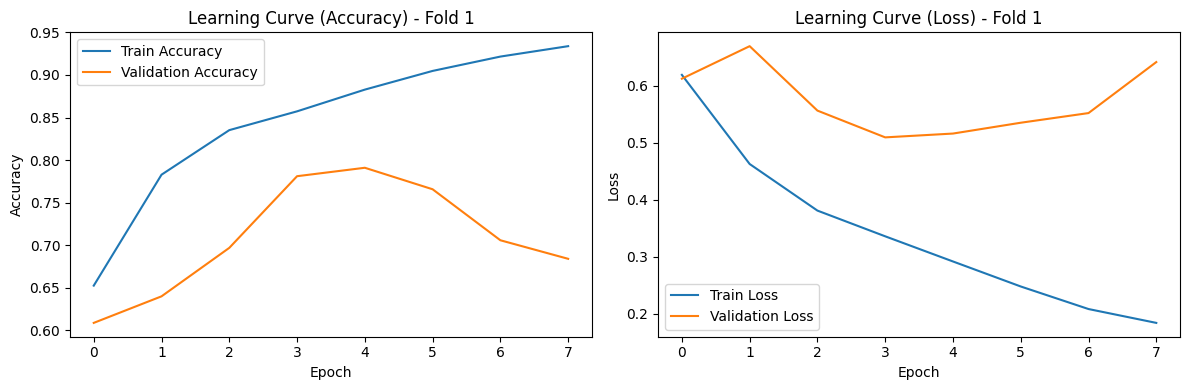

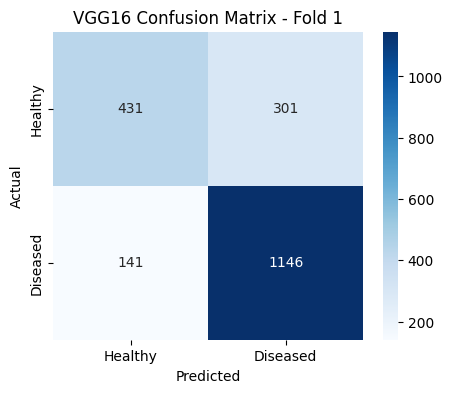


==================== Model 1 (VGG16): Fold 2/5 ====================
Epoch 1/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 61s 222ms/step - accuracy: 0.6850 - loss: 0.5661 - val_accuracy: 0.6720 - val_loss: 0.6671
Epoch 2/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.8410 - loss: 0.3757 - val_accuracy: 0.5614 - val_loss: 0.8022
Epoch 3/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 199ms/step - accuracy: 0.8957 - loss: 0.2602 - val_accuracy: 0.4879 - val_loss: 1.0655
Epoch 4/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 200ms/step - accuracy: 0.9203 - loss: 0.1924 - val_accuracy: 0.6734 - val_loss: 1.1985
Epoch 5/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 200ms/step - accuracy: 0.9416 - loss: 0.1519 - val_accuracy: 0.6420 - val_loss: 1.3029

--- Results for Fold 2 ---
Accuracy: 0.6720
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.30      0.08      0.13       610
    Diseased       0.71      0.92      0.80      1460

    accuracy                           0.67 

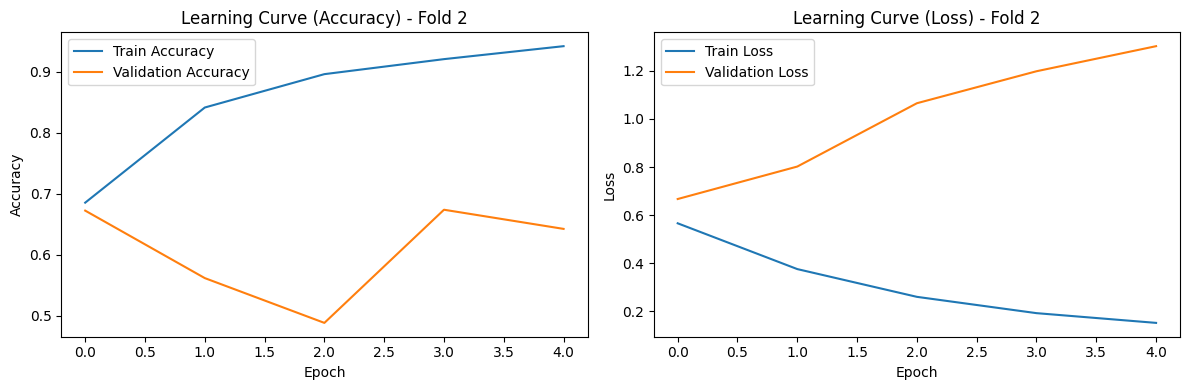

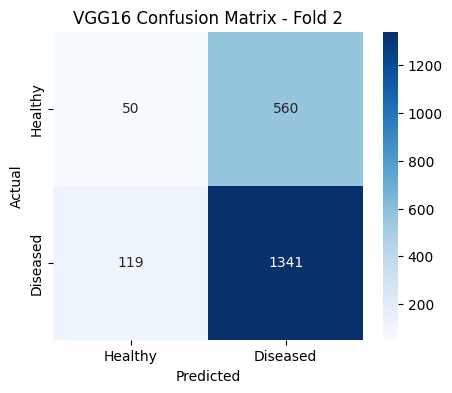


==================== Model 1 (VGG16): Fold 3/5 ====================
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 217ms/step - accuracy: 0.6143 - loss: 0.6337 - val_accuracy: 0.8168 - val_loss: 0.5318
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.7381 - loss: 0.4975 - val_accuracy: 0.7606 - val_loss: 0.4771
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.8100 - loss: 0.4114 - val_accuracy: 0.7558 - val_loss: 0.4714
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.8410 - loss: 0.3523 - val_accuracy: 0.8075 - val_loss: 0.4251
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.8595 - loss: 0.3205 - val_accuracy: 0.7465 - val_loss: 0.5030
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.8915 - loss: 0.2683 - val_accuracy: 0.7525 - val_loss: 0.5080
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.9020 - loss: 0.2326 - val_accuracy: 0.8019 - val_loss: 0.4310
Epoch 8/15
250

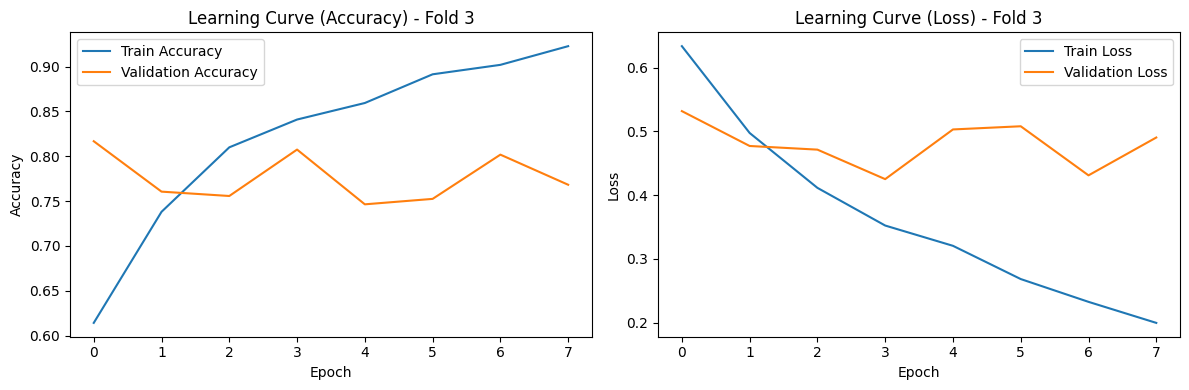

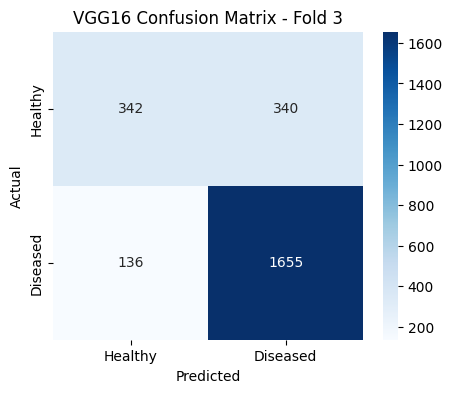


==================== Model 1 (VGG16): Fold 4/5 ====================
Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 59s 212ms/step - accuracy: 0.6368 - loss: 0.6138 - val_accuracy: 0.3721 - val_loss: 0.8121
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.7760 - loss: 0.4619 - val_accuracy: 0.6623 - val_loss: 0.5680
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.8214 - loss: 0.3841 - val_accuracy: 0.5930 - val_loss: 0.7552
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.8541 - loss: 0.3348 - val_accuracy: 0.7002 - val_loss: 0.6295
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.8752 - loss: 0.2890 - val_accuracy: 0.7187 - val_loss: 0.6320
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy: 0.9049 - loss: 0.2381 - val_accuracy: 0.7401 - val_loss: 0.6291

--- Results for Fold 4 ---
Accuracy: 0.6623
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.4

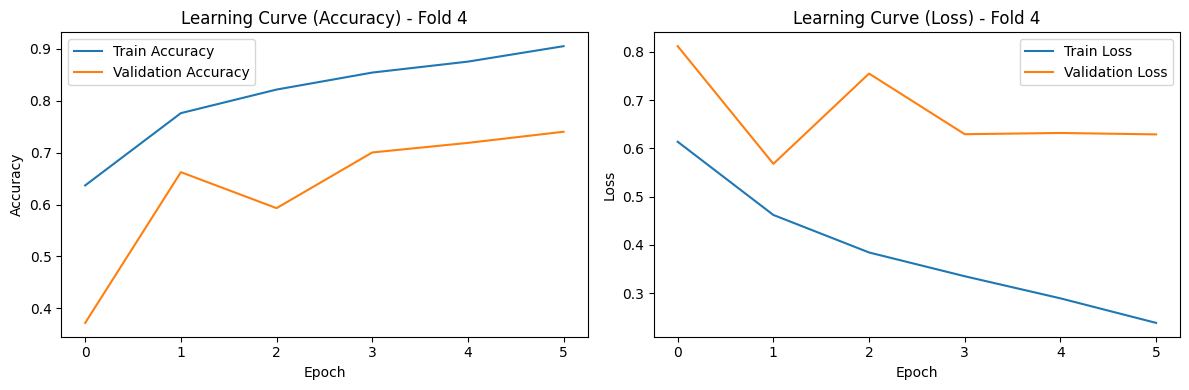

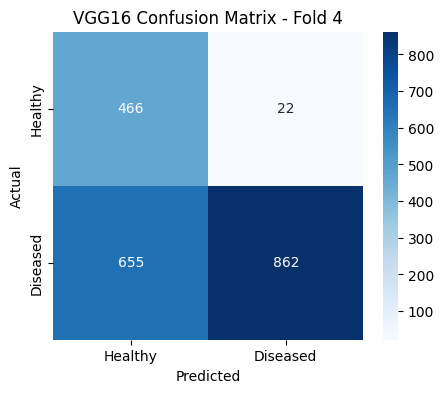


==================== Model 1 (VGG16): Fold 5/5 ====================
Epoch 1/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 61s 218ms/step - accuracy: 0.6316 - loss: 0.6213 - val_accuracy: 0.6752 - val_loss: 0.5739
Epoch 2/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.7682 - loss: 0.4869 - val_accuracy: 0.6587 - val_loss: 0.5668
Epoch 3/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.8137 - loss: 0.4087 - val_accuracy: 0.7675 - val_loss: 0.4364
Epoch 4/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.8477 - loss: 0.3564 - val_accuracy: 0.8240 - val_loss: 0.3472
Epoch 5/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.8829 - loss: 0.2944 - val_accuracy: 0.6683 - val_loss: 0.6747
Epoch 6/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.8961 - loss: 0.2539 - val_accuracy: 0.8533 - val_loss: 0.2960
Epoch 7/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.9163 - loss: 0.2169 - val_accuracy: 0.8565 - val_loss: 0.2934
Epoch 8/15
268

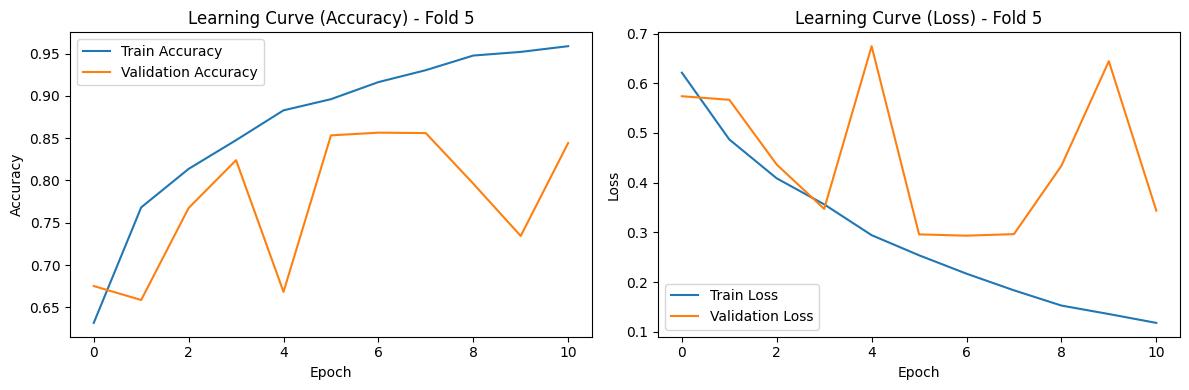

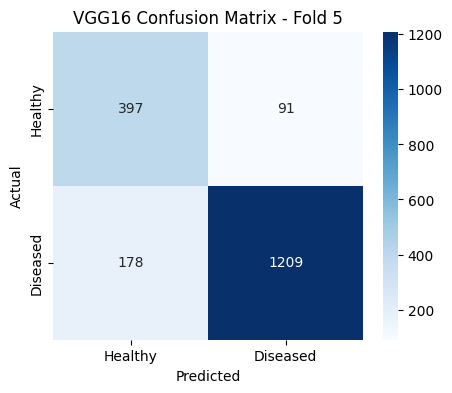


OVERALL VGG16 PERFORMANCE
Overall Accuracy: 0.7565

Overall Classification Report:
              precision    recall  f1-score   support

     Healthy       0.58      0.56      0.57      3000
    Diseased       0.83      0.83      0.83      7442

    accuracy                           0.76     10442
   macro avg       0.70      0.70      0.70     10442
weighted avg       0.75      0.76      0.76     10442



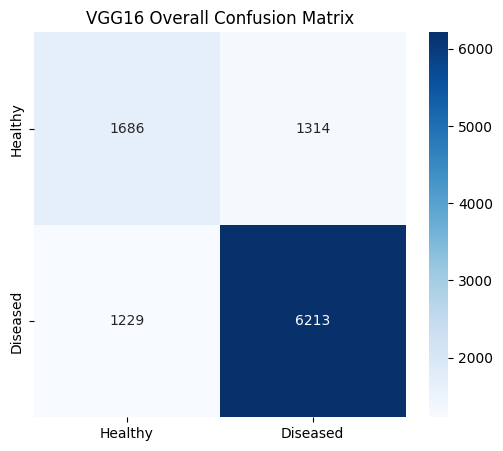

In [ ]:
# Spatial augmentation layers for transfer learning models
data_augmentation_vgg = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Containers for tracking performance across all folds
all_y_true_vgg, all_y_pred_vgg = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_patients, patient_labels)):
    fold_num = fold + 1
    print(f"\n{'='*20} Model 1 (VGG16): Fold {fold_num}/{NUM_FOLDS} {'='*20}")

    # Isolate training and validation images based on patient IDs
    train_images = [img for pid in all_patients[train_idx] for img in patient_dict[pid]]
    val_images = [img for pid in all_patients[val_idx] for img in patient_dict[pid]]

    # Address class imbalance by computing balanced class weights
    train_labels = [get_binary_label(p) for p in train_images]
    cw = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = dict(enumerate(cw))

    # Generate datasets
    train_ds = build_dataset(train_images, shuffle=True)
    val_ds = build_dataset(val_images, shuffle=False)

    # Initialize VGG16 with pre-trained ImageNet weights
    base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    base_model.trainable = True

    # Freeze the first blocks and unfreeze the last 4 layers for fine-tuning
    for layer in base_model.layers[:-4]:
        layer.trainable = False

    # Build the sequential model architecture
    model = models.Sequential([
        data_augmentation_vgg,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Regularization to prevent overfitting
        layers.Dense(1, activation='sigmoid') # Binary output
    ])

    # Compile with specified learning rate and optimizer
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

    # Halt training if the validation loss fails to improve
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    # Execute training phase (Added history assignment here)
    history = model.fit(train_ds, validation_data=val_ds, epochs=15, class_weight=class_weights, callbacks=[early_stopping], verbose=1)

    # Generate predictions for the current fold
    y_probs = model.predict(val_ds, verbose=0)
    y_pred = (y_probs > 0.5).astype("int32").flatten()
    y_true = np.concatenate([labels.numpy() for _, labels in val_ds])

    # Aggregate results for overall reporting
    all_y_true_vgg.extend(y_true)
    all_y_pred_vgg.extend(y_pred)

    # Print detailed metrics for the current fold
    print(f"\n--- Results for Fold {fold_num} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased'], zero_division=1))

    # Plot Learning Curves
    plt.figure(figsize=(12, 4))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Learning Curve (Accuracy) - Fold {fold_num}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Learning Curve (Loss) - Fold {fold_num}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Visualize fold confusion matrix with labels
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Diseased'],
                yticklabels=['Healthy', 'Diseased'])
    plt.title(f'VGG16 Confusion Matrix - Fold {fold_num}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Final Overall Results for VGG16
print("\n" + "="*50 + "\nOVERALL VGG16 PERFORMANCE\n" + "="*50)
print(f"Overall Accuracy: {accuracy_score(all_y_true_vgg, all_y_pred_vgg):.4f}")
print("\nOverall Classification Report:")
print(classification_report(all_y_true_vgg, all_y_pred_vgg, target_names=['Healthy', 'Diseased'], zero_division=1))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_y_true_vgg, all_y_pred_vgg),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'])
plt.title('VGG16 Overall Confusion Matrix')
plt.show()

## 3. Model 2: MobileNetV2 (Lightweight CNN)

**MobileNetV2** is an advanced architecture designed for high resource efficiency while maintaining robust classification accuracy. This model is included to benchmark a deep, heavy network against an energy-efficient, lightweight alternative:

* **Architectural Efficiency:** A `GlobalAveragePooling2D` layer is used to significantly reduce dimensionality before the final dense layer, minimizing the total number of trainable parameters.
* **Training Management:** The `EarlyStopping` mechanism is configured with higher flexibility (Patience = 6), granting the model ample epochs to reach optimal convergence.
* **Data Balancing:** Class weights are computed dynamically for each cross-validation fold to address dataset imbalance without artificially distorting the original medical images.


==================== Model 2 (MobileNetV2): Fold 1/5 ====================
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.5084 - loss: 0.7424 - val_accuracy: 0.5121 - val_loss: 0.6968
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.5669 - loss: 0.7176 - val_accuracy: 0.5121 - val_loss: 0.6951
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.5891 - loss: 0.7032 - val_accuracy: 0.5171 - val_loss: 0.6968
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.6014 - loss: 0.6902 - val_accuracy: 0.5220 - val_loss: 0.6964
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.6077 - loss: 0.6899 - val_accuracy: 0.5270 - val_loss: 0.6947
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - accuracy: 0.6220 - loss: 0.6784 - val_accuracy: 0.5339 - val_loss: 0.6898
Epoch 7/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.6112 - loss: 0.6863 - val_ac

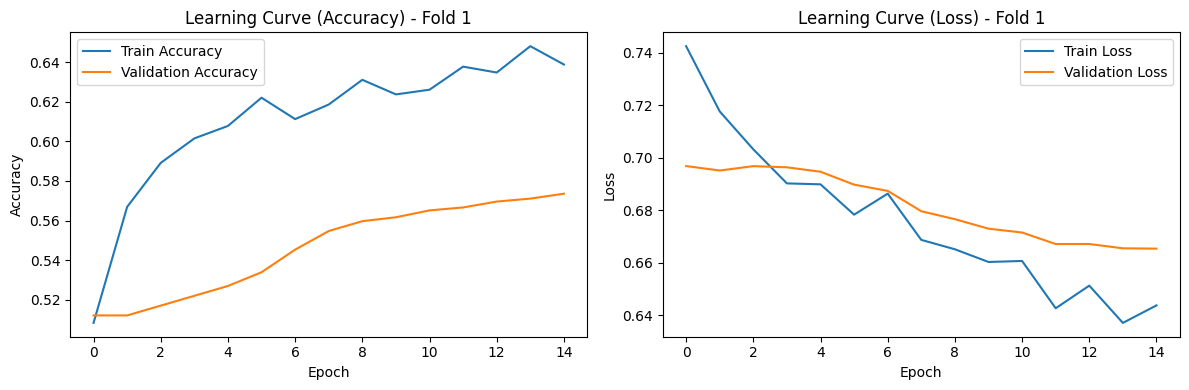

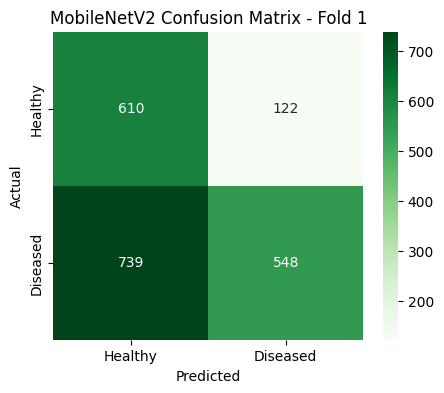


==================== Model 2 (MobileNetV2): Fold 2/5 ====================
Epoch 1/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.4595 - loss: 0.7956 - val_accuracy: 0.3556 - val_loss: 1.0750
Epoch 2/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.5299 - loss: 0.7475 - val_accuracy: 0.3816 - val_loss: 0.9073
Epoch 3/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.5581 - loss: 0.7262 - val_accuracy: 0.4097 - val_loss: 0.8291
Epoch 4/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.5663 - loss: 0.7120 - val_accuracy: 0.4425 - val_loss: 0.7802
Epoch 5/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.5946 - loss: 0.6864 - val_accuracy: 0.4758 - val_loss: 0.7505
Epoch 6/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6169 - loss: 0.6683 - val_accuracy: 0.4952 - val_loss: 0.7346
Epoch 7/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.6206 - loss: 0.6601 - val_accuracy: 0.5048 - val_loss: 0.7270
Epoch 8/15
262/

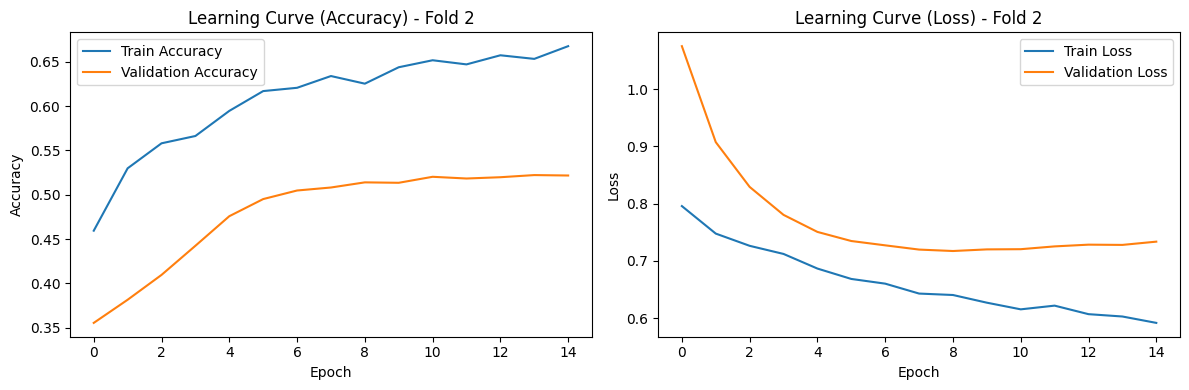

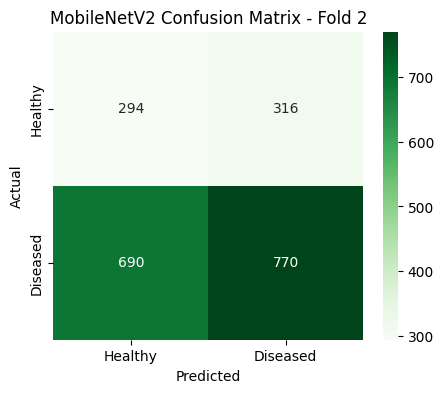


==================== Model 2 (MobileNetV2): Fold 3/5 ====================
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.5503 - loss: 0.7259 - val_accuracy: 0.5273 - val_loss: 0.6868
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.5713 - loss: 0.7098 - val_accuracy: 0.5754 - val_loss: 0.6532
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.5917 - loss: 0.6926 - val_accuracy: 0.6090 - val_loss: 0.6333
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.5844 - loss: 0.6982 - val_accuracy: 0.6247 - val_loss: 0.6244
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.6016 - loss: 0.6852 - val_accuracy: 0.6385 - val_loss: 0.6148
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.5997 - loss: 0.6861 - val_accuracy: 0.6466 - val_loss: 0.6083
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.6042 - loss: 0.6733 - val_accuracy: 0.6522 - val_loss: 0.6017
Epoch 8/15
250/

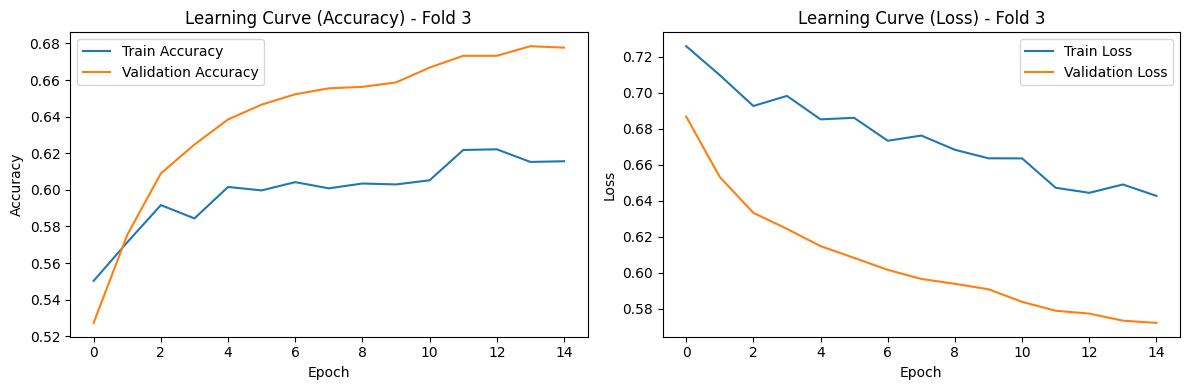

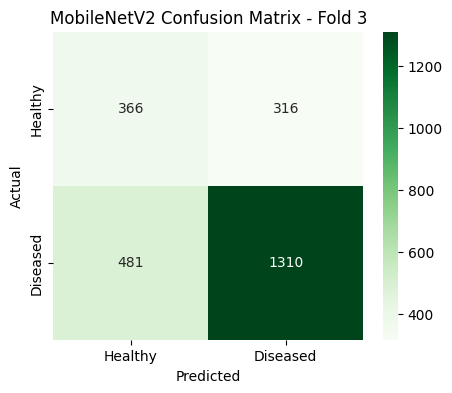


==================== Model 2 (MobileNetV2): Fold 4/5 ====================
Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.5905 - loss: 0.8583 - val_accuracy: 0.5751 - val_loss: 0.6597
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.5491 - loss: 0.8138 - val_accuracy: 0.5212 - val_loss: 0.6841
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.5470 - loss: 0.7761 - val_accuracy: 0.5132 - val_loss: 0.6895
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.5458 - loss: 0.7600 - val_accuracy: 0.5197 - val_loss: 0.6917
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.5414 - loss: 0.7568 - val_accuracy: 0.5252 - val_loss: 0.6929
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.5567 - loss: 0.7348 - val_accuracy: 0.5332 - val_loss: 0.6894
Epoch 7/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.5675 - loss: 0.7203 - val_accuracy: 0.5262 - val_loss: 0.6894

--- Results fo

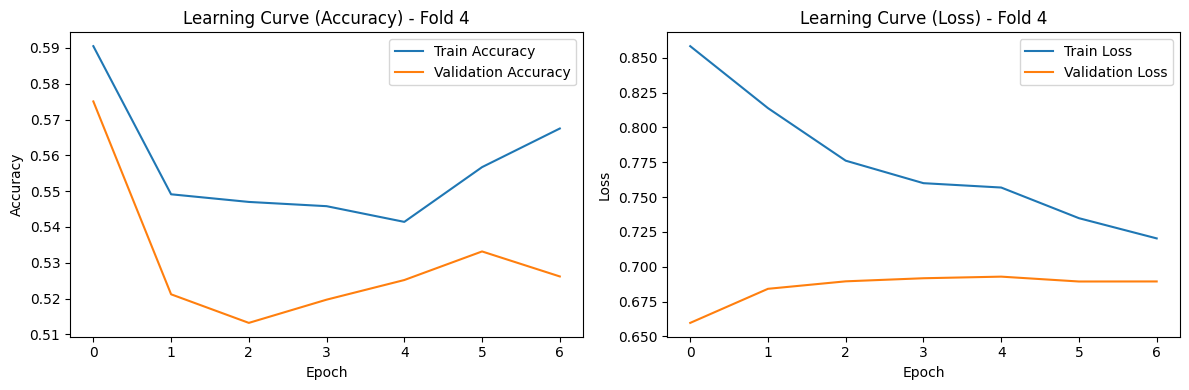

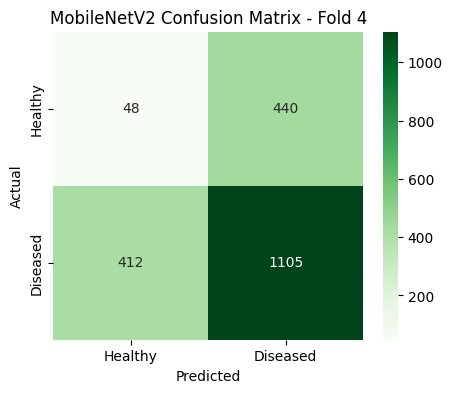


==================== Model 2 (MobileNetV2): Fold 5/5 ====================
Epoch 1/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.6226 - loss: 0.7193 - val_accuracy: 0.5792 - val_loss: 0.6590
Epoch 2/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - accuracy: 0.6063 - loss: 0.6976 - val_accuracy: 0.5680 - val_loss: 0.6601
Epoch 3/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.5967 - loss: 0.6977 - val_accuracy: 0.5643 - val_loss: 0.6545
Epoch 4/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6063 - loss: 0.6890 - val_accuracy: 0.5861 - val_loss: 0.6423
Epoch 5/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.5920 - loss: 0.6865 - val_accuracy: 0.6032 - val_loss: 0.6309
Epoch 6/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.6034 - loss: 0.6786 - val_accuracy: 0.6155 - val_loss: 0.6218
Epoch 7/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6097 - loss: 0.6690 - val_accuracy: 0.6245 - val_loss: 0.6153
Epoch 8/15
268/

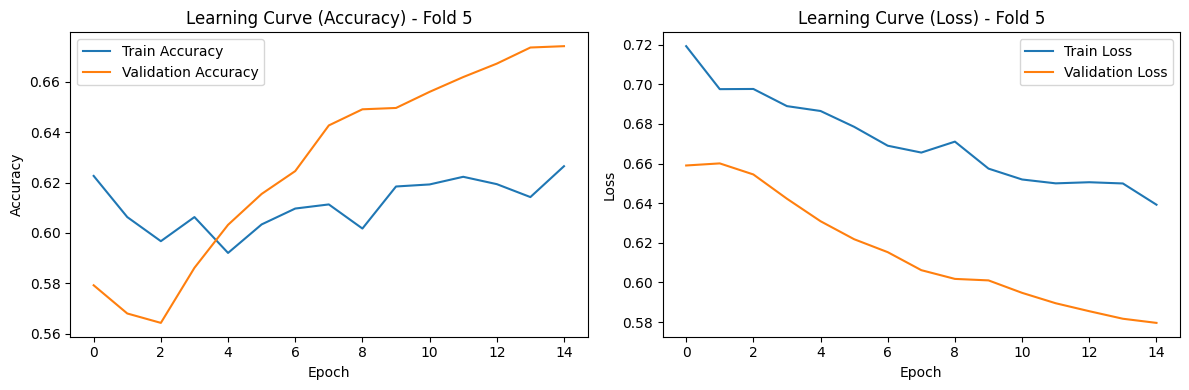

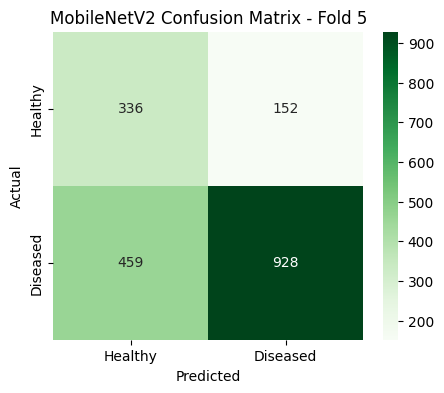


OVERALL MOBILENETV2 PERFORMANCE
Overall Accuracy: 0.6048

Overall Classification Report:
              precision    recall  f1-score   support

     Healthy       0.37      0.55      0.44      3000
    Diseased       0.78      0.63      0.69      7442

    accuracy                           0.60     10442
   macro avg       0.57      0.59      0.57     10442
weighted avg       0.66      0.60      0.62     10442



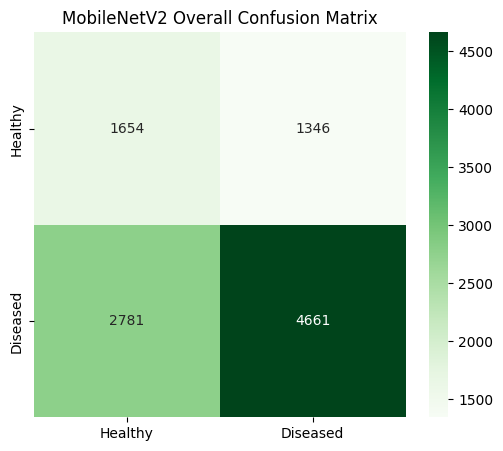

In [ ]:
# Containers for tracking performance across all folds
all_y_true_mn, all_y_pred_mn = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_patients, patient_labels)):
    fold_num = fold + 1
    print(f"\n{'='*20} Model 2 (MobileNetV2): Fold {fold_num}/{NUM_FOLDS} {'='*20}")

    # Patient-based data partitioning
    train_images = [img for pid in all_patients[train_idx] for img in patient_dict[pid]]
    val_images = [img for pid in all_patients[val_idx] for img in patient_dict[pid]]

    # Re-calculate class weights for every fold to address imbalance
    train_labels = [get_binary_label(p) for p in train_images]
    cw = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = dict(enumerate(cw))

    train_ds = build_dataset(train_images, shuffle=True)
    val_ds = build_dataset(val_images, shuffle=False)

    # Load MobileNetV2 architecture
    base_model = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    base_model.trainable = True

    # Freeze layers except the last 2 layers as specified
    for layer in base_model.layers[:-2]:
        layer.trainable = False

    # Build sequential model including data augmentation
    model = models.Sequential([
        data_augmentation_vgg, # Shared transfer learning augmentation
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile with Adam optimizer and low learning rate
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

    # Patience set to 6 as per original source
    early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

    # Execute training phase (Added history assignment here)
    history = model.fit(train_ds, validation_data=val_ds, epochs=15, class_weight=class_weights, callbacks=[early_stopping], verbose=1)

    # Generate predictions
    y_probs = model.predict(val_ds, verbose=0)
    y_pred = (y_probs > 0.5).astype("int32").flatten()
    y_true = np.concatenate([labels.numpy() for _, labels in val_ds])

    all_y_true_mn.extend(y_true)
    all_y_pred_mn.extend(y_pred)

    # Print metrics for the current fold
    print(f"\n--- Results for Fold {fold_num} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased'], zero_division=1))

    # Plot Learning Curves
    plt.figure(figsize=(12, 4))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Learning Curve (Accuracy) - Fold {fold_num}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Learning Curve (Loss) - Fold {fold_num}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Visualize fold confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt='d', cmap='Greens',
                xticklabels=['Healthy', 'Diseased'],
                yticklabels=['Healthy', 'Diseased'])
    plt.title(f'MobileNetV2 Confusion Matrix - Fold {fold_num}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Final Overall Results for MobileNetV2
print("\n" + "="*50 + "\nOVERALL MOBILENETV2 PERFORMANCE\n" + "="*50)
print(f"Overall Accuracy: {accuracy_score(all_y_true_mn, all_y_pred_mn):.4f}")
print("\nOverall Classification Report:")
print(classification_report(all_y_true_mn, all_y_pred_mn, target_names=['Healthy', 'Diseased'], zero_division=1))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_y_true_mn, all_y_pred_mn),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'])
plt.title('MobileNetV2 Overall Confusion Matrix')
plt.show()

## 4. Model 3: Custom CNN Architecture

This section introduces a **Custom Convolutional Neural Network (CNN)** built entirely from scratch for this specific medical imaging task. It serves as a strong baseline to evaluate the performance of transfer learning approaches:

* **Architectural Design:** The network consists of sequential blocks of `Conv2D`, `BatchNormalization`, and `MaxPooling2D` to extract hierarchical features effectively. An `L2` regularizer is applied to the dense layer to penalize overly complex weights and enhance generalization.
* **Advanced Loss Function:** `BinaryFocalCrossentropy` (with gamma=2) is employed to force the model to focus on hard-to-classify examples, which is highly advantageous for imbalanced medical datasets.
* **Dynamic Learning Rate:** A `ReduceLROnPlateau` callback is implemented to automatically reduce the learning rate by a factor of 0.3 when the validation loss plateaus, ensuring precise optimization during the final stages of training.


==================== Model 3 (Custom CNN): Fold 1/5 ====================
Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 38s 133ms/step - accuracy: 0.7514 - loss: 0.1813 - val_accuracy: 0.3626 - val_loss: 0.5609 - learning_rate: 3.0000e-04
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 34s 128ms/step - accuracy: 0.8385 - loss: 0.1380 - val_accuracy: 0.7008 - val_loss: 0.1744 - learning_rate: 3.0000e-04
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.8548 - loss: 0.1248 - val_accuracy: 0.5111 - val_loss: 0.5691 - learning_rate: 3.0000e-04
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 34s 128ms/step - accuracy: 0.8657 - loss: 0.1166 - val_accuracy: 0.6582 - val_loss: 0.2788 - learning_rate: 3.0000e-04
Epoch 5/20
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8775 - loss: 0.1102
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.8770 - loss: 0.1079 - val_accuracy: 0.6924 - val_loss: 0.2060 - lear

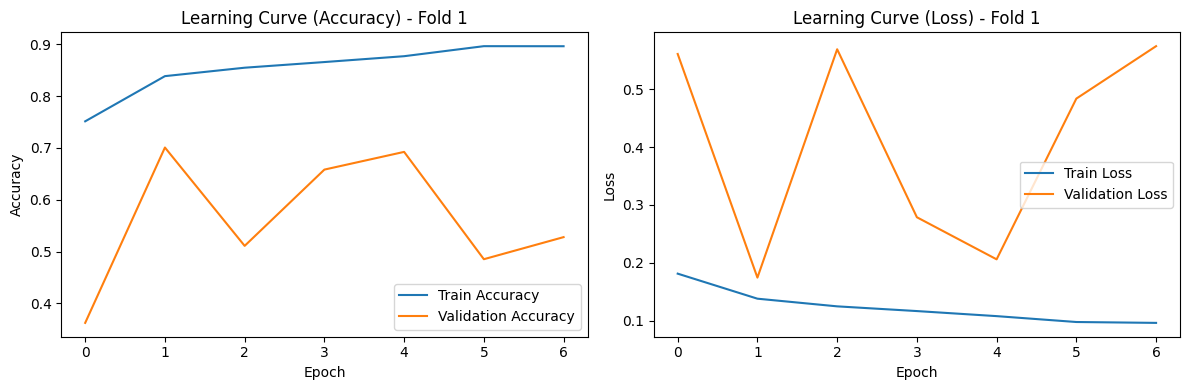

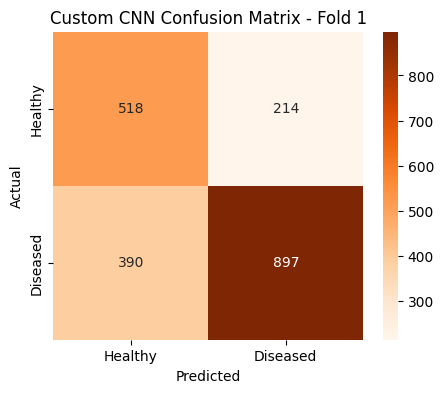


==================== Model 3 (Custom CNN): Fold 2/5 ====================
Epoch 1/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 38s 134ms/step - accuracy: 0.7536 - loss: 0.1808 - val_accuracy: 0.2947 - val_loss: 1.0999 - learning_rate: 3.0000e-04
Epoch 2/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.8349 - loss: 0.1374 - val_accuracy: 0.7193 - val_loss: 0.1765 - learning_rate: 3.0000e-04
Epoch 3/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.8592 - loss: 0.1187 - val_accuracy: 0.7720 - val_loss: 0.1494 - learning_rate: 3.0000e-04
Epoch 4/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.8703 - loss: 0.1086 - val_accuracy: 0.7391 - val_loss: 0.1494 - learning_rate: 3.0000e-04
Epoch 5/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.8931 - loss: 0.0968 - val_accuracy: 0.5623 - val_loss: 0.2726 - learning_rate: 3.0000e-04
Epoch 6/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9015 - loss: 0.0904
Epoch 6: ReduceLROnPlateau reducing learnin

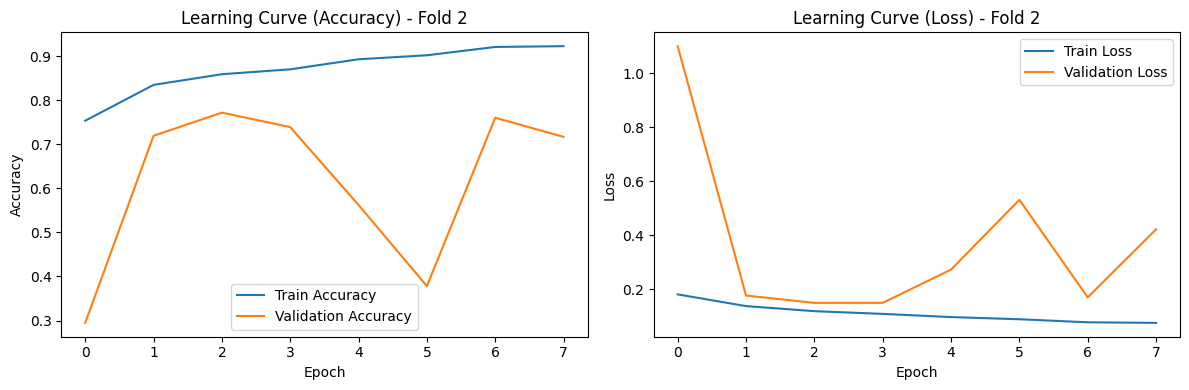

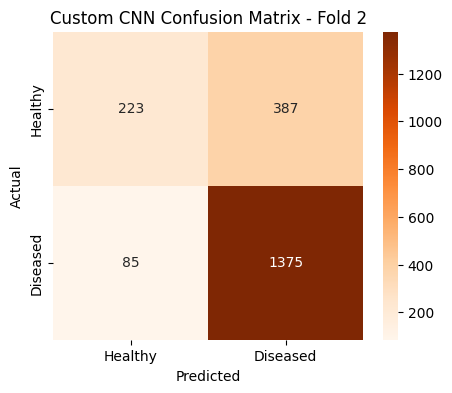


==================== Model 3 (Custom CNN): Fold 3/5 ====================
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 135ms/step - accuracy: 0.7320 - loss: 0.1856 - val_accuracy: 0.2758 - val_loss: 0.3616 - learning_rate: 3.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.7911 - loss: 0.1522 - val_accuracy: 0.5382 - val_loss: 0.2197 - learning_rate: 3.0000e-04
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.8197 - loss: 0.1392 - val_accuracy: 0.7396 - val_loss: 0.1694 - learning_rate: 3.0000e-04
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - accuracy: 0.8285 - loss: 0.1315 - val_accuracy: 0.7545 - val_loss: 0.1578 - learning_rate: 3.0000e-04
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.8409 - loss: 0.1235 - val_accuracy: 0.8035 - val_loss: 0.1325 - learning_rate: 3.0000e-04
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.8502 - loss: 0.1152 - val_accuracy: 0.3793 - val_loss: 0.3603 

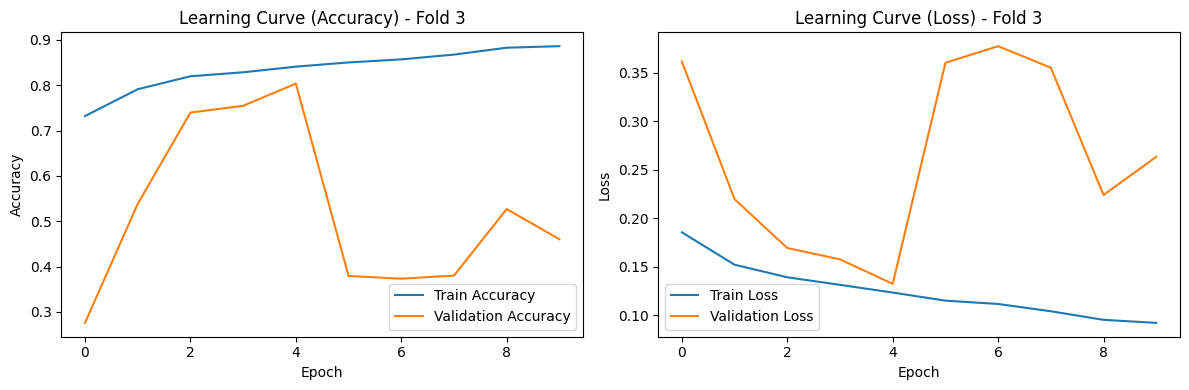

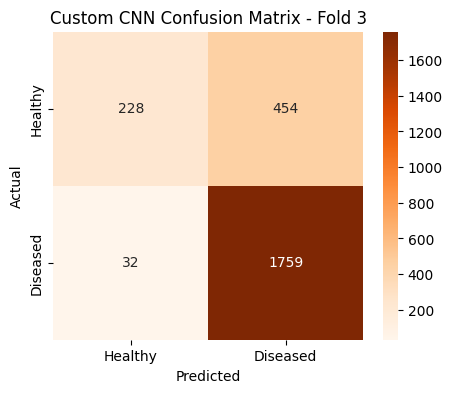


==================== Model 3 (Custom CNN): Fold 4/5 ====================
Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.7289 - loss: 0.1875 - val_accuracy: 0.2434 - val_loss: 0.4893 - learning_rate: 3.0000e-04
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.8025 - loss: 0.1503 - val_accuracy: 0.9327 - val_loss: 0.1125 - learning_rate: 3.0000e-04
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.8415 - loss: 0.1294 - val_accuracy: 0.4494 - val_loss: 0.3153 - learning_rate: 3.0000e-04
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.8598 - loss: 0.1169 - val_accuracy: 0.8928 - val_loss: 0.1076 - learning_rate: 3.0000e-04
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.8741 - loss: 0.1091 - val_accuracy: 0.9401 - val_loss: 0.0694 - learning_rate: 3.0000e-04
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.8872 - loss: 0.1025 - val_accuracy: 0.5117 - val_loss: 0.3937 

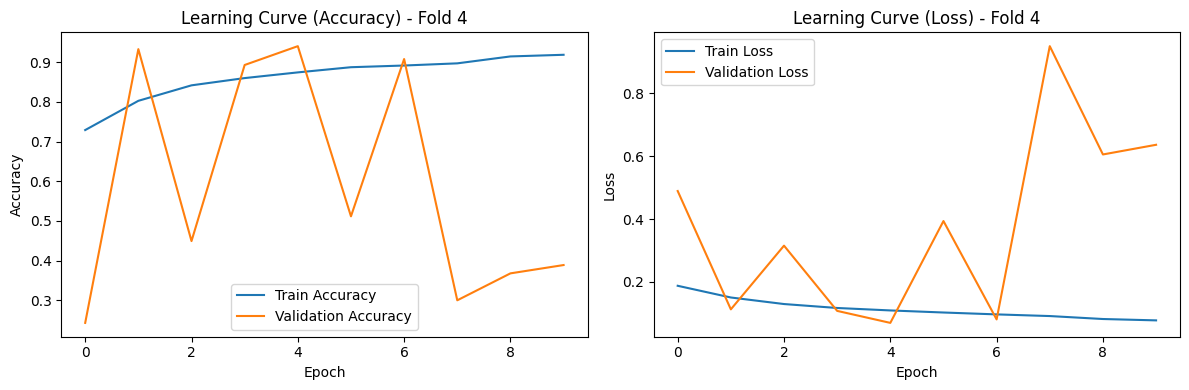

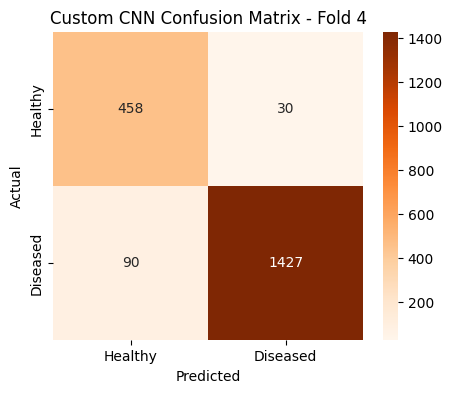


==================== Model 3 (Custom CNN): Fold 5/5 ====================
Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 39s 134ms/step - accuracy: 0.7409 - loss: 0.1819 - val_accuracy: 0.2603 - val_loss: 0.3297 - learning_rate: 3.0000e-04
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.8146 - loss: 0.1439 - val_accuracy: 0.7397 - val_loss: 0.2681 - learning_rate: 3.0000e-04
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.8396 - loss: 0.1280 - val_accuracy: 0.7824 - val_loss: 0.1752 - learning_rate: 3.0000e-04
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 35s 130ms/step - accuracy: 0.8571 - loss: 0.1167 - val_accuracy: 0.5792 - val_loss: 0.2602 - learning_rate: 3.0000e-04
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 35s 130ms/step - accuracy: 0.8728 - loss: 0.1084 - val_accuracy: 0.7248 - val_loss: 0.1848 - learning_rate: 3.0000e-04
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.8806 - loss: 0.1012 - val_accuracy: 0.8080 - val_loss: 0.1395 

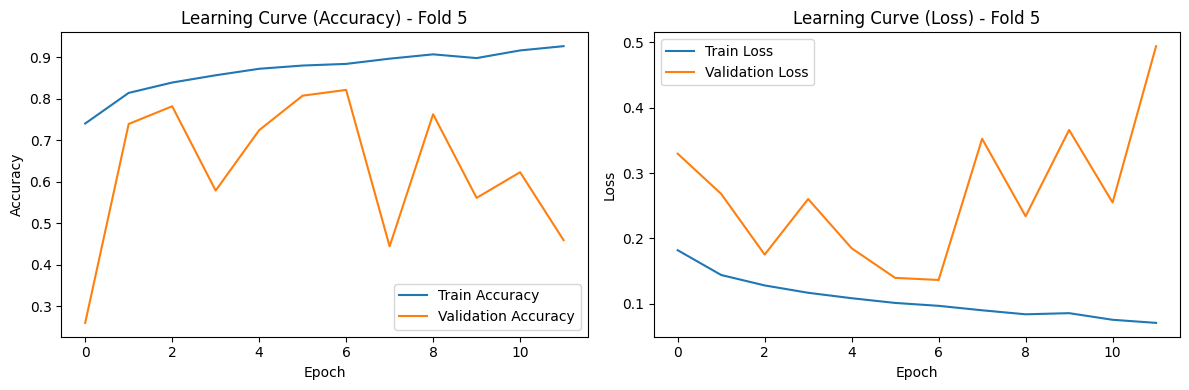

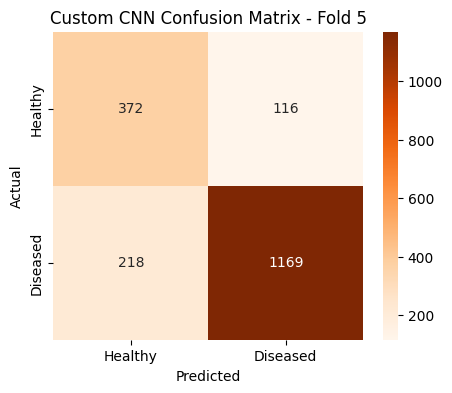


OVERALL CUSTOM CNN PERFORMANCE
Overall Accuracy: 0.8069

Overall Classification Report:
              precision    recall  f1-score   support

     Healthy       0.69      0.60      0.64      3000
    Diseased       0.85      0.89      0.87      7442

    accuracy                           0.81     10442
   macro avg       0.77      0.75      0.75     10442
weighted avg       0.80      0.81      0.80     10442



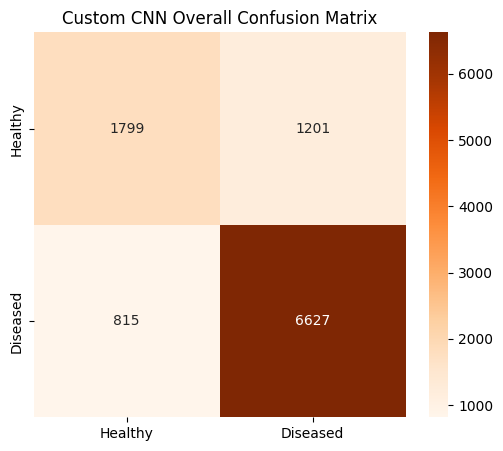

In [ ]:
# Specialized augmentation logic for the Custom CNN model
data_augmentation_custom = tf.keras.Sequential([
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05)
])

# Containers for tracking performance across all folds
all_y_true_cnn, all_y_pred_cnn = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_patients, patient_labels)):
    fold_num = fold + 1
    print(f"\n{'='*20} Model 3 (Custom CNN): Fold {fold_num}/{NUM_FOLDS} {'='*20}")

    train_images = [img for pid in all_patients[train_idx] for img in patient_dict[pid]]
    val_images = [img for pid in all_patients[val_idx] for img in patient_dict[pid]]

    train_labels = [get_binary_label(p) for p in train_images]
    cw = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = dict(enumerate(cw))

    train_ds = build_dataset(train_images, shuffle=True)
    val_ds = build_dataset(val_images, shuffle=False)

    # Custom CNN architecture with Batch Normalization for training speed and stability
    model = models.Sequential([
        layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        data_augmentation_custom,
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        # Dense layer with L2 regularization to discourage large weights
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])

    # Binary Focal Loss to handle class imbalance more effectively than standard crossentropy
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
        metrics=['accuracy']
    )

    # Setup callbacks for early stopping and adaptive learning rate
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)

    # Training execution (Added history assignment here)
    history = model.fit(train_ds, validation_data=val_ds, epochs=20, class_weight=class_weights, callbacks=[early_stop, reduce_lr], verbose=1)

    # Perform inference and collect results
    y_probs = model.predict(val_ds, verbose=0)
    y_pred = (y_probs > 0.5).astype("int32").flatten()
    y_true = np.concatenate([labels.numpy() for _, labels in val_ds])

    all_y_true_cnn.extend(y_true)
    all_y_pred_cnn.extend(y_pred)

    # Print metrics for the current fold
    print(f"\n--- Results for Fold {fold_num} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased'], zero_division=1))

    # Plot Learning Curves
    plt.figure(figsize=(12, 4))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Learning Curve (Accuracy) - Fold {fold_num}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Learning Curve (Loss) - Fold {fold_num}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Healthy', 'Diseased'],
                yticklabels=['Healthy', 'Diseased'])
    plt.title(f'Custom CNN Confusion Matrix - Fold {fold_num}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Final Overall Results for Custom CNN
print("\n" + "="*50 + "\nOVERALL CUSTOM CNN PERFORMANCE\n" + "="*50)
print(f"Overall Accuracy: {accuracy_score(all_y_true_cnn, all_y_pred_cnn):.4f}")
print("\nOverall Classification Report:")
print(classification_report(all_y_true_cnn, all_y_pred_cnn, target_names=['Healthy', 'Diseased'], zero_division=1))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_y_true_cnn, all_y_pred_cnn),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'])
plt.title('Custom CNN Overall Confusion Matrix')
plt.show()

## 5. Model 4: Enhanced VGG16 Architecture (SMOTE + Grid Search)

This section extends the standard **VGG16** transfer learning approach by incorporating advanced techniques to improve performance and generalization for Alzheimer's MRI classification:

* **Fine-Tuning:** The pre-trained VGG16 model is used with ImageNet weights. Early layers are frozen, while the last **4 layers** are unfrozen to adapt to domain-specific brain scan features.

* **Training Strategy:** A simple **Grid Search** is applied over learning rates (`1e-4`, `1e-5`) and dropout rates (`0.3`, `0.5`). The model uses the Adam optimizer along with `EarlyStopping` (patience = 4) and `ReduceLROnPlateau` to enhance convergence and reduce overfitting.

* **Class Imbalance Handling:** **SMOTE** is used to balance the training data by resampling indices, ensuring better representation of both classes.

* **Regularization:** Additional techniques such as **Dropout**, **L2 regularization**, and **Batch Normalization** are applied to improve stability and reduce overfitting.

* **Integrated Preprocessing:** Data augmentation layers are embedded within the model, applying random transformations only during training to improve generalization.


  Testing config: LR=0.0001, Dropout=0.3

==================== Model 4 (VGG16 with SMOTE): Fold 1/5 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 185ms/step - accuracy: 0.8793 - loss: 0.4602 - val_accuracy: 0.7408 - val_loss: 0.7425 - learning_rate: 1.0000e-04
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.9686 - loss: 0.2485 - val_accuracy: 0.8647 - val_loss: 0.4745 - learning_rate: 1.0000e-04
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - accuracy: 0.9827 - loss: 0.1908 - val_accuracy: 0.6376 - val_loss: 2.2359 - learning_rate: 1.0000e-04
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9906 - loss: 0.1501 - val_accuracy: 0.8709 - val_loss: 1.0355 - learning_rate: 1.0000e-04
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9969 - loss: 0.1257 - val_accuracy: 0.8497 - val_loss: 0.6178 - learning_rate: 3.0000e-05
Epoch 6/15
391/391 ━━━━━━━━━━━━━

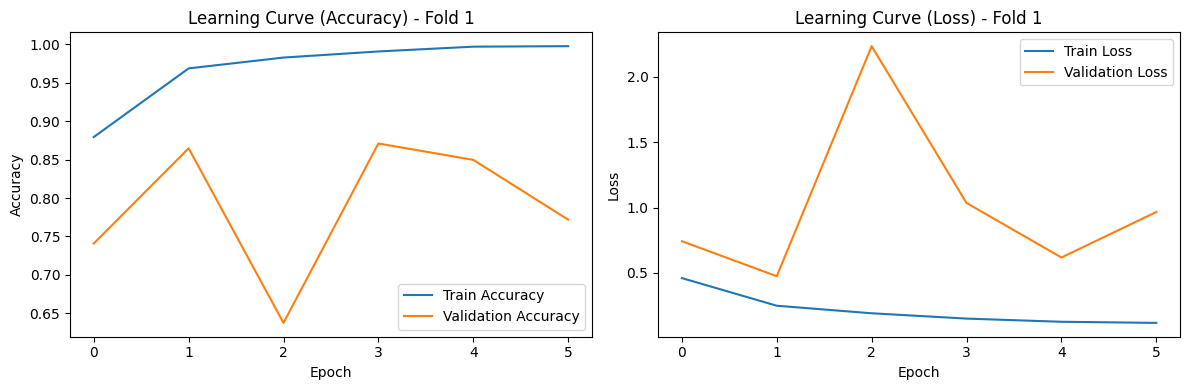

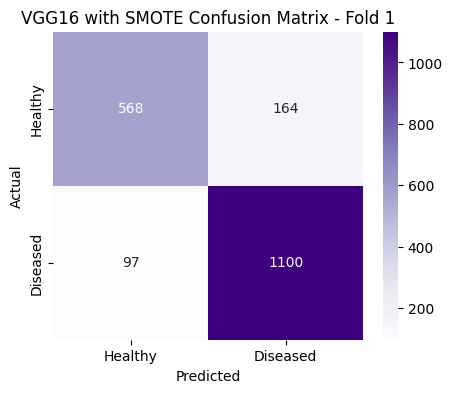


==================== Model 4 (VGG16 with SMOTE): Fold 2/5 ====================
Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 84s 206ms/step - accuracy: 0.9241 - loss: 0.3753 - val_accuracy: 0.4807 - val_loss: 1.6052 - learning_rate: 1.0000e-04
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9787 - loss: 0.2233 - val_accuracy: 0.6733 - val_loss: 2.3528 - learning_rate: 1.0000e-04
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9875 - loss: 0.1794 - val_accuracy: 0.6579 - val_loss: 3.0509 - learning_rate: 1.0000e-04
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9967 - loss: 0.1425 - val_accuracy: 0.6867 - val_loss: 3.1001 - learning_rate: 3.0000e-05
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9983 - loss: 0.1319 - val_accuracy: 0.7093 - val_loss: 3.2493 - learning_rate: 3.0000e-05

--- Results for Fold 2 ---
Accuracy: 0.4807
Classification Report:
              precision    recall  f1-score   support

  

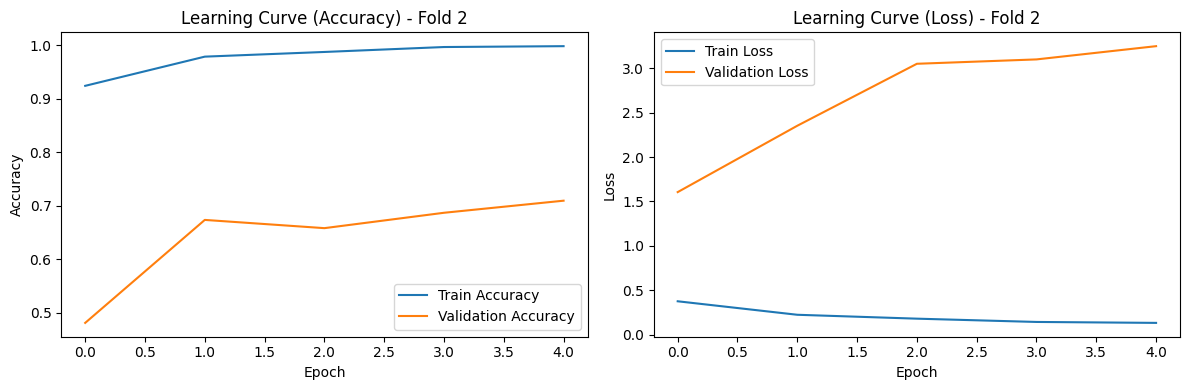

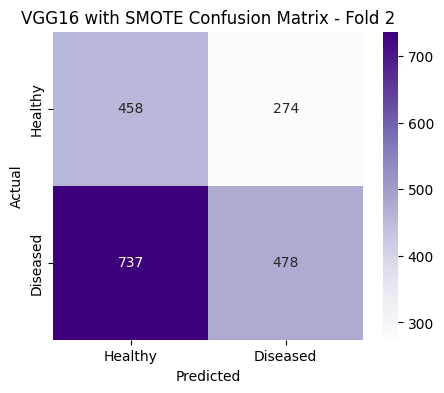


==================== Model 4 (VGG16 with SMOTE): Fold 3/5 ====================
Epoch 1/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 76s 214ms/step - accuracy: 0.8843 - loss: 0.4532 - val_accuracy: 0.7065 - val_loss: 0.8012 - learning_rate: 1.0000e-04
Epoch 2/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 205ms/step - accuracy: 0.9724 - loss: 0.2503 - val_accuracy: 0.7506 - val_loss: 0.8314 - learning_rate: 1.0000e-04
Epoch 3/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 204ms/step - accuracy: 0.9800 - loss: 0.2029 - val_accuracy: 0.6287 - val_loss: 1.4982 - learning_rate: 1.0000e-04
Epoch 4/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 79s 234ms/step - accuracy: 0.9950 - loss: 0.1556 - val_accuracy: 0.8629 - val_loss: 0.7947 - learning_rate: 3.0000e-05
Epoch 5/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 204ms/step - accuracy: 0.9974 - loss: 0.1432 - val_accuracy: 0.8626 - val_loss: 0.6625 - learning_rate: 3.0000e-05
Epoch 6/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 204ms/step - accuracy: 0.9965 - loss: 0.1399 - val_accuracy: 0.8614 - val_loss: 0

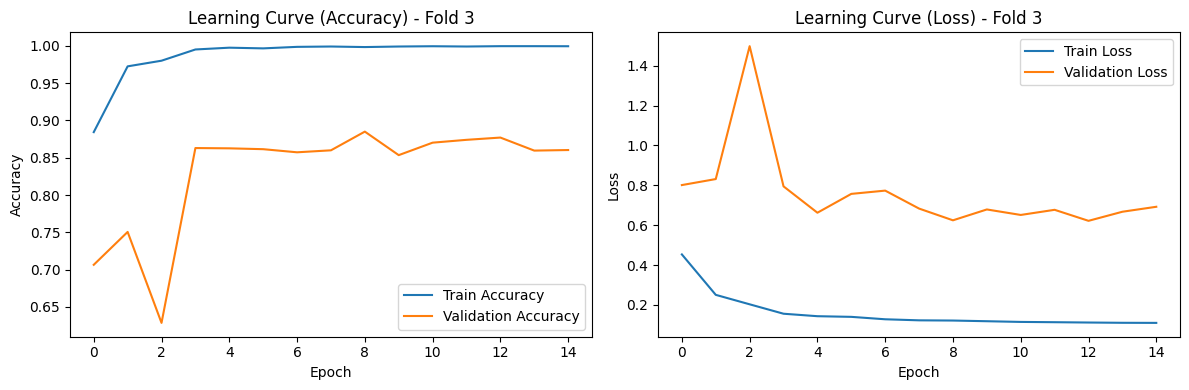

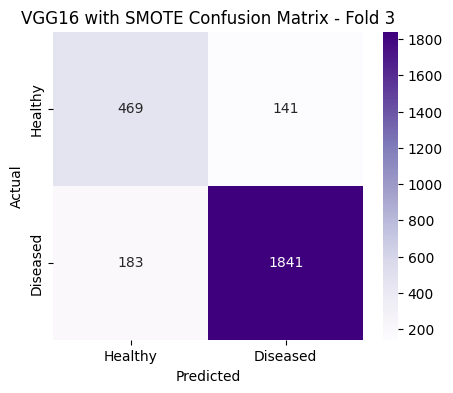


==================== Model 4 (VGG16 with SMOTE): Fold 4/5 ====================
Epoch 1/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 78s 198ms/step - accuracy: 0.9061 - loss: 0.4004 - val_accuracy: 0.8351 - val_loss: 0.9184 - learning_rate: 1.0000e-04
Epoch 2/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9801 - loss: 0.2149 - val_accuracy: 0.7465 - val_loss: 1.2934 - learning_rate: 1.0000e-04
Epoch 3/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9823 - loss: 0.1790 - val_accuracy: 0.6091 - val_loss: 1.5894 - learning_rate: 1.0000e-04
Epoch 4/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 195ms/step - accuracy: 0.9931 - loss: 0.1430 - val_accuracy: 0.8160 - val_loss: 1.3726 - learning_rate: 3.0000e-05
Epoch 5/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9966 - loss: 0.1250 - val_accuracy: 0.7439 - val_loss: 1.4552 - learning_rate: 3.0000e-05

--- Results for Fold 4 ---
Accuracy: 0.8351
Classification Report:
              precision    recall  f1-score   support

  

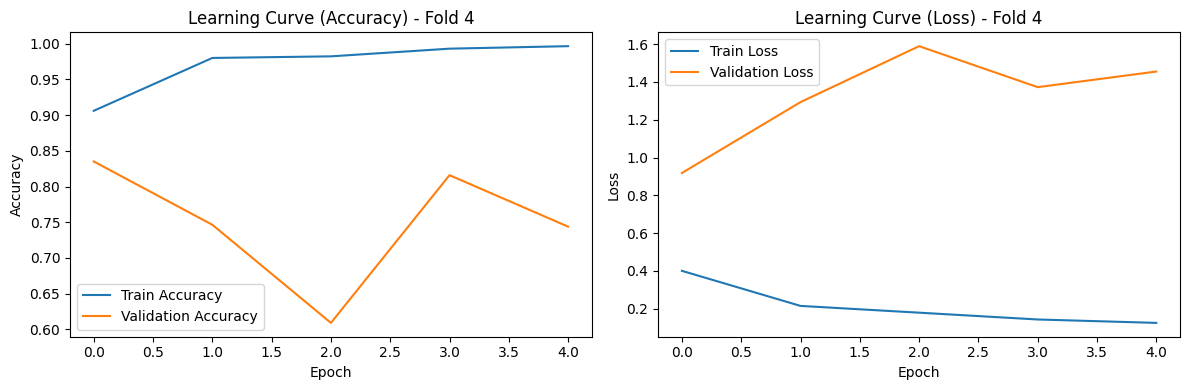

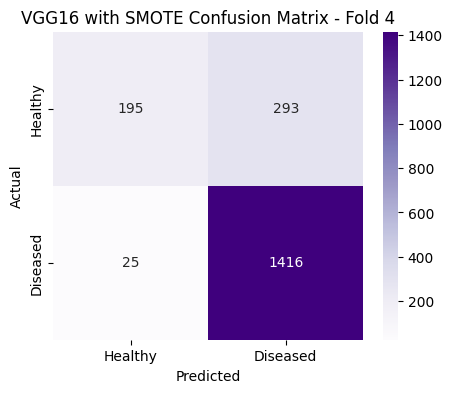


==================== Model 4 (VGG16 with SMOTE): Fold 5/5 ====================
Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 78s 205ms/step - accuracy: 0.8777 - loss: 0.4612 - val_accuracy: 0.8283 - val_loss: 0.6290 - learning_rate: 1.0000e-04
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 79s 197ms/step - accuracy: 0.9638 - loss: 0.2567 - val_accuracy: 0.7259 - val_loss: 0.9243 - learning_rate: 1.0000e-04
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9860 - loss: 0.1820 - val_accuracy: 0.7369 - val_loss: 1.4756 - learning_rate: 1.0000e-04
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9950 - loss: 0.1466 - val_accuracy: 0.8028 - val_loss: 0.9257 - learning_rate: 3.0000e-05
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9965 - loss: 0.1343 - val_accuracy: 0.8377 - val_loss: 0.7782 - learning_rate: 3.0000e-05

--- Results for Fold 5 ---
Accuracy: 0.8283
Classification Report:
              precision    recall  f1-score   support

  

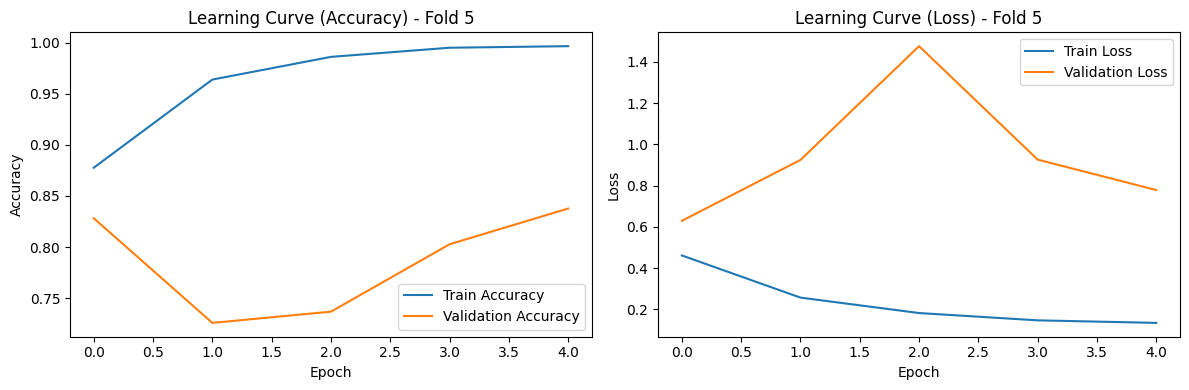

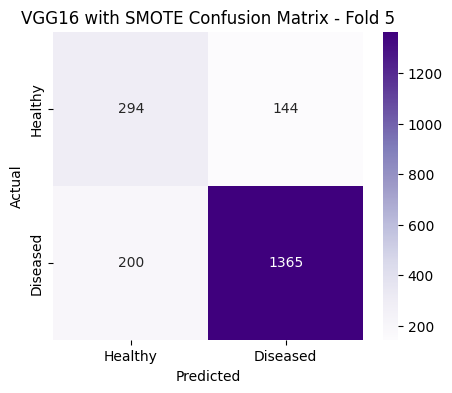


✅ Config Result → Accuracy: 0.7838

  Testing config: LR=0.0001, Dropout=0.5

==================== Model 4 (VGG16 with SMOTE): Fold 1/5 ====================
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 196ms/step - accuracy: 0.8540 - loss: 0.5007 - val_accuracy: 0.7398 - val_loss: 0.7755 - learning_rate: 1.0000e-04
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9589 - loss: 0.2591 - val_accuracy: 0.7864 - val_loss: 0.9516 - learning_rate: 1.0000e-04
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9779 - loss: 0.1874 - val_accuracy: 0.7807 - val_loss: 0.7923 - learning_rate: 1.0000e-04
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9939 - loss: 0.1342 - val_accuracy: 0.8279 - val_loss: 0.8296 - learning_rate: 3.0000e-05
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - accuracy: 0.9958 - loss: 0.1224 - val_accuracy: 0.8232 - val_loss: 0.7857 - learning_rate: 3.0000e-05

--- Results for Fold 1 ---
Accuracy: 0.7398
Cl

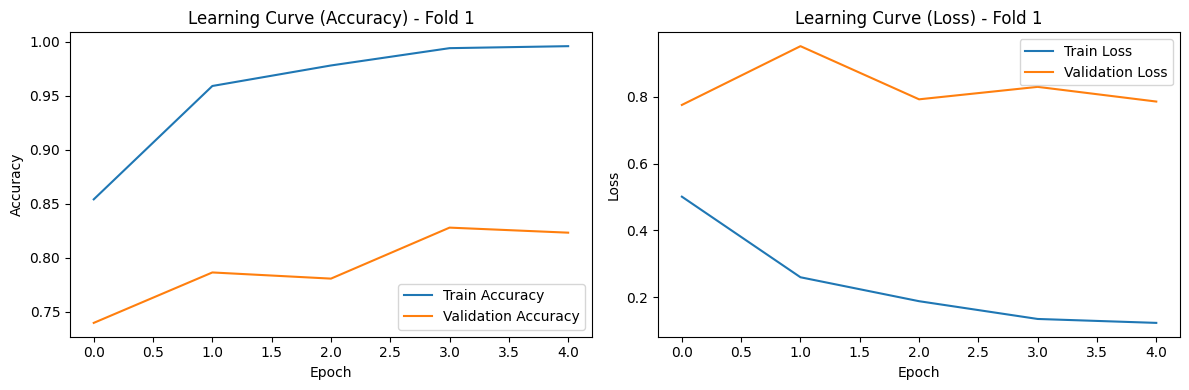

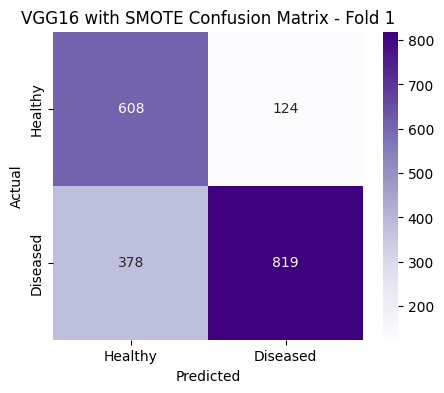


==================== Model 4 (VGG16 with SMOTE): Fold 2/5 ====================
Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 80s 197ms/step - accuracy: 0.9026 - loss: 0.4162 - val_accuracy: 0.6281 - val_loss: 1.3072 - learning_rate: 1.0000e-04
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.9734 - loss: 0.2309 - val_accuracy: 0.4607 - val_loss: 3.1469 - learning_rate: 1.0000e-04
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9842 - loss: 0.1841 - val_accuracy: 0.6995 - val_loss: 3.6906 - learning_rate: 1.0000e-04
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.9945 - loss: 0.1478 - val_accuracy: 0.6852 - val_loss: 4.0205 - learning_rate: 3.0000e-05
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.9960 - loss: 0.1378 - val_accuracy: 0.6713 - val_loss: 4.0697 - learning_rate: 3.0000e-05

--- Results for Fold 2 ---
Accuracy: 0.6281
Classification Report:
              precision    recall  f1-score   support

  

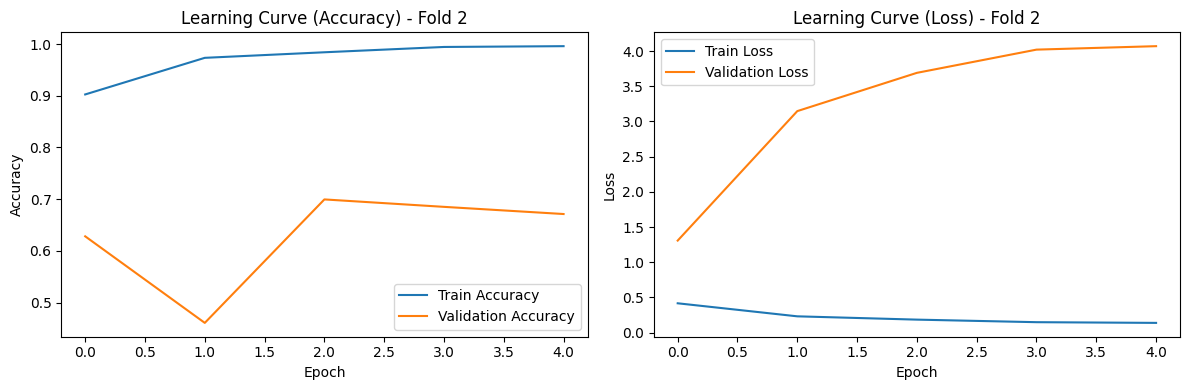

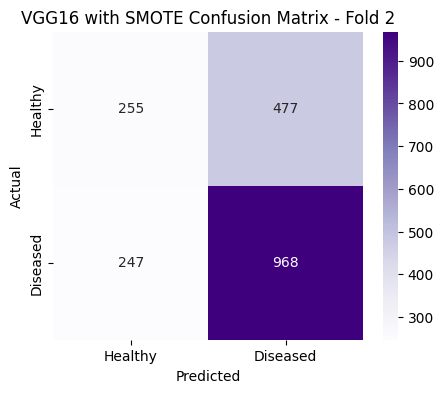


==================== Model 4 (VGG16 with SMOTE): Fold 3/5 ====================
Epoch 1/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 74s 208ms/step - accuracy: 0.8600 - loss: 0.5036 - val_accuracy: 0.7399 - val_loss: 0.6824 - learning_rate: 1.0000e-04
Epoch 2/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9600 - loss: 0.2738 - val_accuracy: 0.8212 - val_loss: 0.6241 - learning_rate: 1.0000e-04
Epoch 3/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 205ms/step - accuracy: 0.9777 - loss: 0.2074 - val_accuracy: 0.8846 - val_loss: 0.8072 - learning_rate: 1.0000e-04
Epoch 4/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9846 - loss: 0.1730 - val_accuracy: 0.8857 - val_loss: 0.5570 - learning_rate: 1.0000e-04
Epoch 5/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9885 - loss: 0.1502 - val_accuracy: 0.8599 - val_loss: 0.5539 - learning_rate: 1.0000e-04
Epoch 6/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.9875 - loss: 0.1394 - val_accuracy: 0.8713 - val_loss: 1

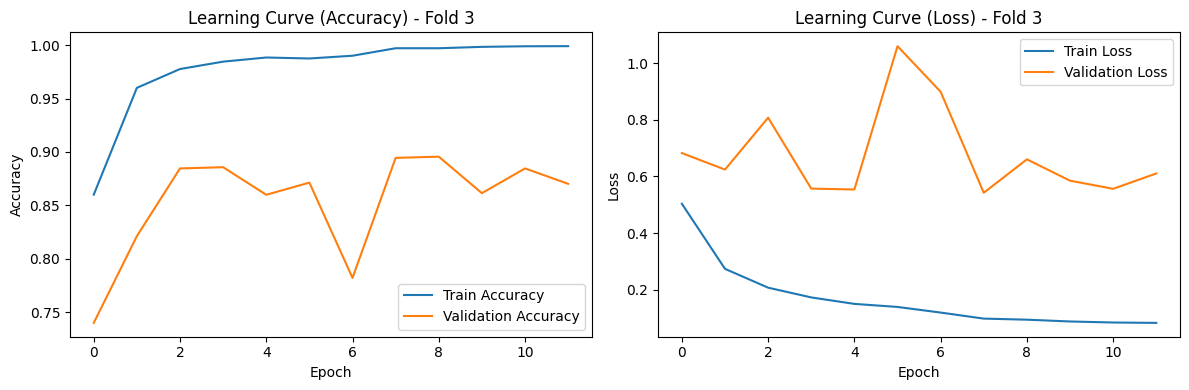

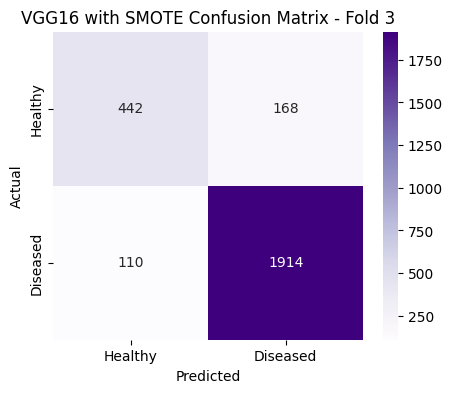


==================== Model 4 (VGG16 with SMOTE): Fold 4/5 ====================
Epoch 1/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 77s 197ms/step - accuracy: 0.8772 - loss: 0.4626 - val_accuracy: 0.7304 - val_loss: 0.9928 - learning_rate: 1.0000e-04
Epoch 2/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 195ms/step - accuracy: 0.9659 - loss: 0.2567 - val_accuracy: 0.6304 - val_loss: 1.4729 - learning_rate: 1.0000e-04
Epoch 3/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 82s 196ms/step - accuracy: 0.9779 - loss: 0.2063 - val_accuracy: 0.4515 - val_loss: 3.0428 - learning_rate: 1.0000e-04
Epoch 4/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9928 - loss: 0.1599 - val_accuracy: 0.7843 - val_loss: 1.6480 - learning_rate: 3.0000e-05
Epoch 5/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9928 - loss: 0.1525 - val_accuracy: 0.6916 - val_loss: 1.7214 - learning_rate: 3.0000e-05

--- Results for Fold 4 ---
Accuracy: 0.7304
Classification Report:
              precision    recall  f1-score   support

  

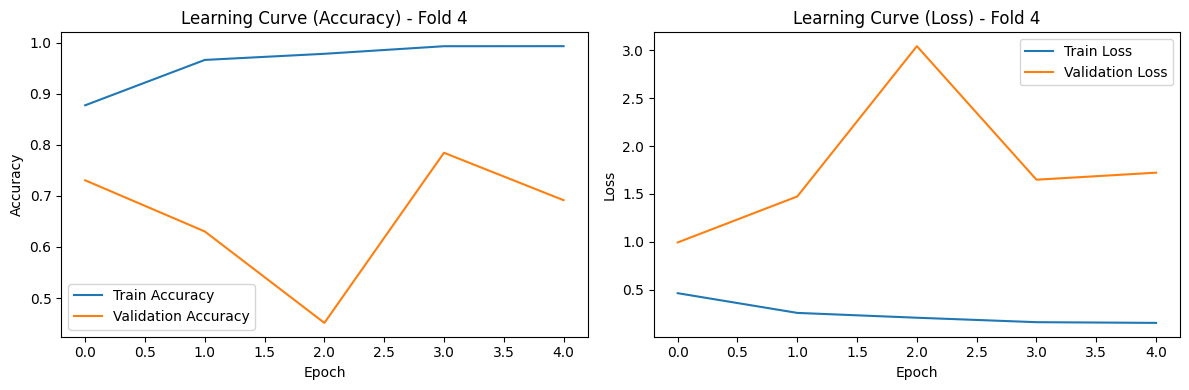

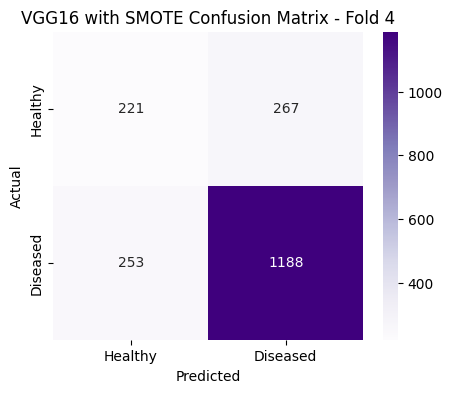


==================== Model 4 (VGG16 with SMOTE): Fold 5/5 ====================
Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 198ms/step - accuracy: 0.8662 - loss: 0.4840 - val_accuracy: 0.8128 - val_loss: 0.7604 - learning_rate: 1.0000e-04
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9591 - loss: 0.2745 - val_accuracy: 0.7843 - val_loss: 0.8694 - learning_rate: 1.0000e-04
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 74s 202ms/step - accuracy: 0.9798 - loss: 0.2039 - val_accuracy: 0.8168 - val_loss: 0.6749 - learning_rate: 1.0000e-04
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9802 - loss: 0.1834 - val_accuracy: 0.7624 - val_loss: 1.0904 - learning_rate: 1.0000e-04
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9850 - loss: 0.1558 - val_accuracy: 0.7723 - val_loss: 0.8767 - learning_rate: 1.0000e-04
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9959 - loss: 0.1220 - val_accuracy: 0.8362 - val_loss: 0

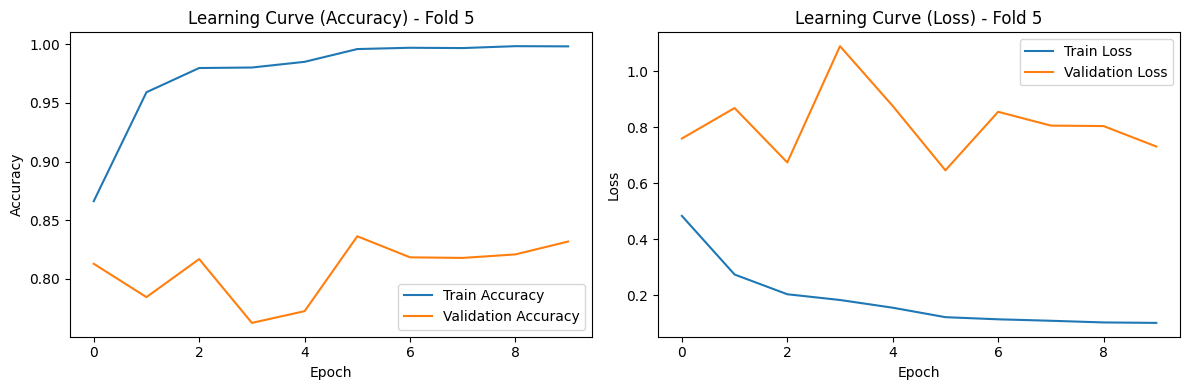

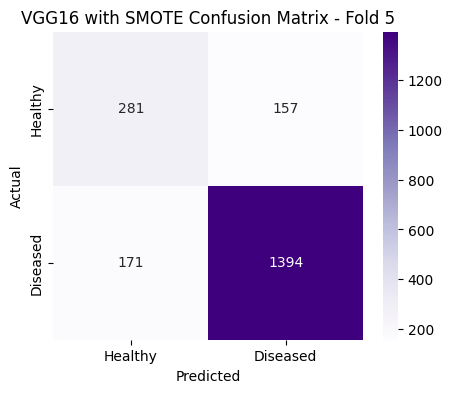


✅ Config Result → Accuracy: 0.7748

  Testing config: LR=1e-05, Dropout=0.3

==================== Model 4 (VGG16 with SMOTE): Fold 1/5 ====================
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 196ms/step - accuracy: 0.7641 - loss: 0.6653 - val_accuracy: 0.7061 - val_loss: 0.7032 - learning_rate: 1.0000e-05
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 194ms/step - accuracy: 0.9121 - loss: 0.4422 - val_accuracy: 0.7672 - val_loss: 0.6410 - learning_rate: 1.0000e-05
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 193ms/step - accuracy: 0.9606 - loss: 0.3373 - val_accuracy: 0.7024 - val_loss: 0.8815 - learning_rate: 1.0000e-05
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9764 - loss: 0.2816 - val_accuracy: 0.7983 - val_loss: 0.6253 - learning_rate: 1.0000e-05
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9841 - loss: 0.2541 - val_accuracy: 0.8009 - val_loss: 0.6405 - learning_rate: 1.0000e-05
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 194m

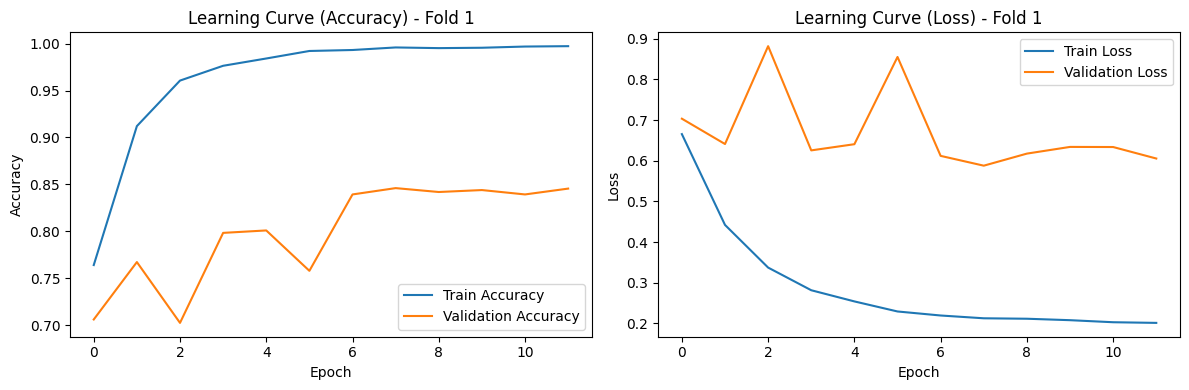

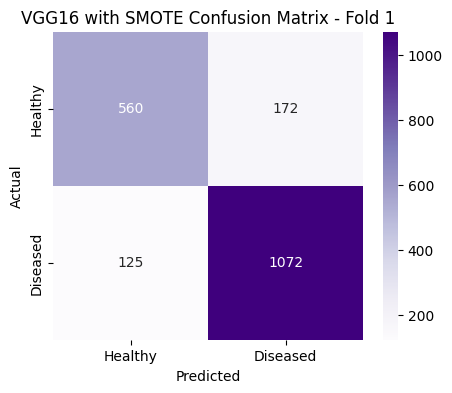


==================== Model 4 (VGG16 with SMOTE): Fold 2/5 ====================
Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 80s 196ms/step - accuracy: 0.8082 - loss: 0.6081 - val_accuracy: 0.6148 - val_loss: 0.8308 - learning_rate: 1.0000e-05
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.9370 - loss: 0.3795 - val_accuracy: 0.6374 - val_loss: 1.1509 - learning_rate: 1.0000e-05
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 194ms/step - accuracy: 0.9722 - loss: 0.2952 - val_accuracy: 0.7062 - val_loss: 1.6761 - learning_rate: 1.0000e-05
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.9823 - loss: 0.2615 - val_accuracy: 0.7108 - val_loss: 1.6874 - learning_rate: 3.0000e-06
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.9854 - loss: 0.2525 - val_accuracy: 0.7052 - val_loss: 1.7098 - learning_rate: 3.0000e-06

--- Results for Fold 2 ---
Accuracy: 0.6148
Classification Report:
              precision    recall  f1-score   support

  

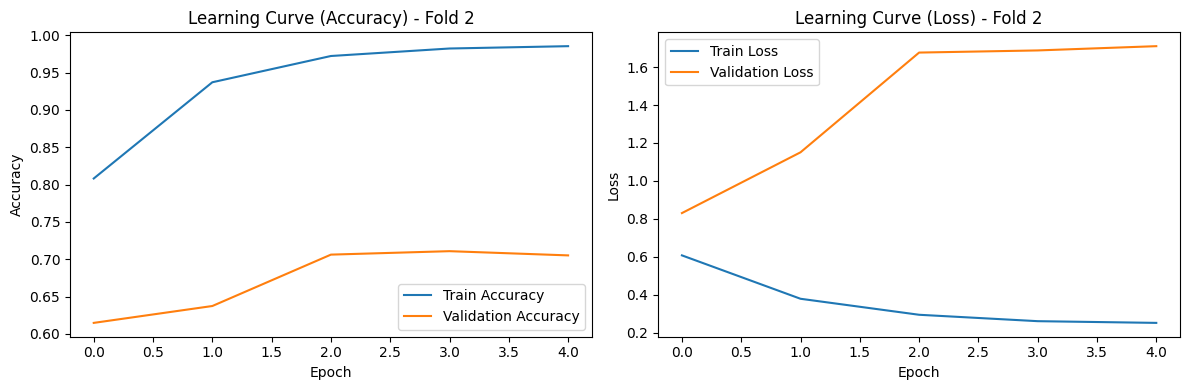

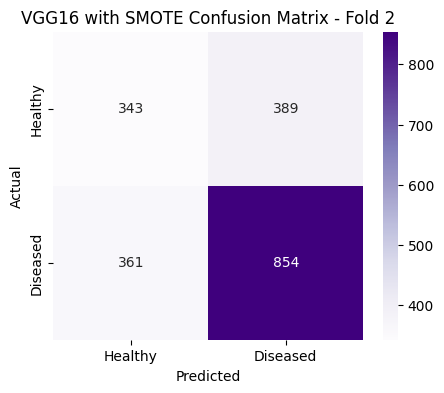


==================== Model 4 (VGG16 with SMOTE): Fold 3/5 ====================
Epoch 1/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 74s 208ms/step - accuracy: 0.7673 - loss: 0.6672 - val_accuracy: 0.7878 - val_loss: 0.7257 - learning_rate: 1.0000e-05
Epoch 2/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9087 - loss: 0.4501 - val_accuracy: 0.7893 - val_loss: 0.6440 - learning_rate: 1.0000e-05
Epoch 3/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9543 - loss: 0.3503 - val_accuracy: 0.8162 - val_loss: 0.6740 - learning_rate: 1.0000e-05
Epoch 4/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9733 - loss: 0.2959 - val_accuracy: 0.8648 - val_loss: 0.5849 - learning_rate: 1.0000e-05
Epoch 5/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.9827 - loss: 0.2641 - val_accuracy: 0.8629 - val_loss: 0.6307 - learning_rate: 1.0000e-05
Epoch 6/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.9866 - loss: 0.2432 - val_accuracy: 0.8231 - val_loss: 0

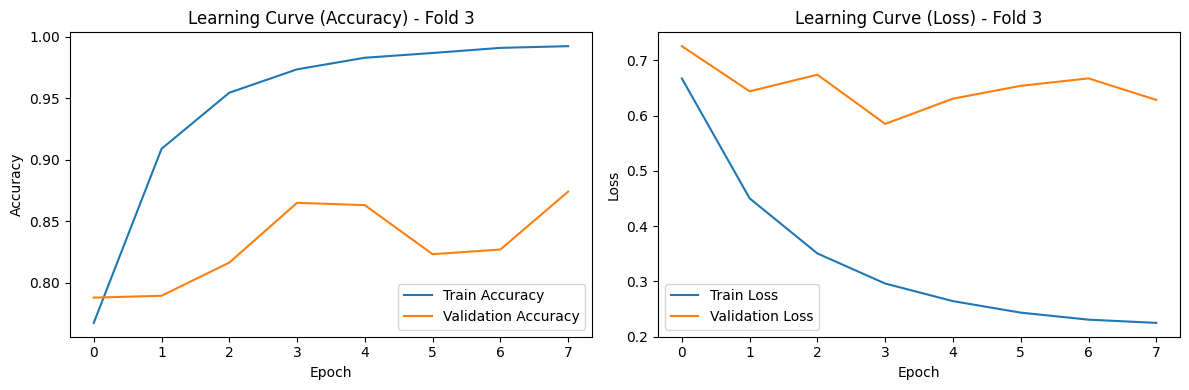

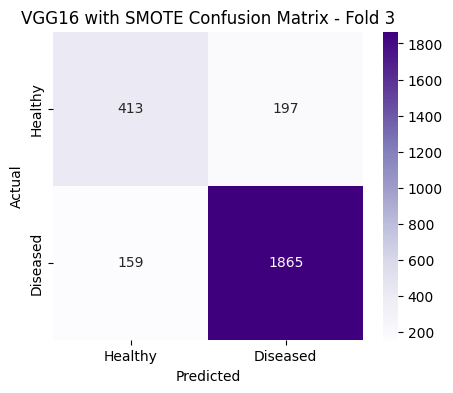


==================== Model 4 (VGG16 with SMOTE): Fold 4/5 ====================
Epoch 1/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.7996 - loss: 0.6177 - val_accuracy: 0.5666 - val_loss: 0.9086 - learning_rate: 1.0000e-05
Epoch 2/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.9288 - loss: 0.4002 - val_accuracy: 0.5816 - val_loss: 1.2021 - learning_rate: 1.0000e-05
Epoch 3/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.9633 - loss: 0.3176 - val_accuracy: 0.7444 - val_loss: 1.0321 - learning_rate: 1.0000e-05
Epoch 4/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.9782 - loss: 0.2799 - val_accuracy: 0.6998 - val_loss: 1.1261 - learning_rate: 3.0000e-06
Epoch 5/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.9805 - loss: 0.2705 - val_accuracy: 0.6262 - val_loss: 1.2615 - learning_rate: 3.0000e-06

--- Results for Fold 4 ---
Accuracy: 0.5666
Classification Report:
              precision    recall  f1-score   support

  

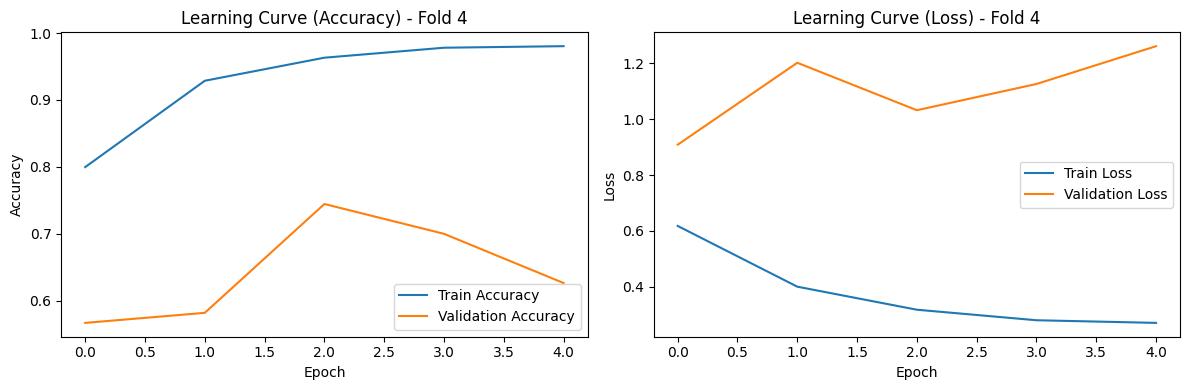

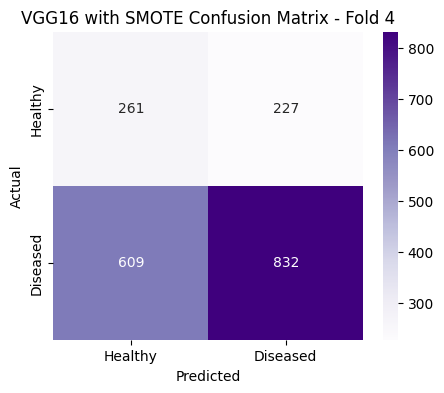


==================== Model 4 (VGG16 with SMOTE): Fold 5/5 ====================
Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 75s 196ms/step - accuracy: 0.7831 - loss: 0.6466 - val_accuracy: 0.6116 - val_loss: 0.8589 - learning_rate: 1.0000e-05
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 82s 196ms/step - accuracy: 0.9077 - loss: 0.4407 - val_accuracy: 0.7439 - val_loss: 0.8476 - learning_rate: 1.0000e-05
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 82s 196ms/step - accuracy: 0.9542 - loss: 0.3429 - val_accuracy: 0.7259 - val_loss: 0.9277 - learning_rate: 1.0000e-05
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 195ms/step - accuracy: 0.9701 - loss: 0.2969 - val_accuracy: 0.8088 - val_loss: 0.8041 - learning_rate: 1.0000e-05
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 194ms/step - accuracy: 0.9808 - loss: 0.2619 - val_accuracy: 0.7988 - val_loss: 0.8804 - learning_rate: 1.0000e-05
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 71s 194ms/step - accuracy: 0.9889 - loss: 0.2364 - val_accuracy: 0.7683 - val_loss: 0

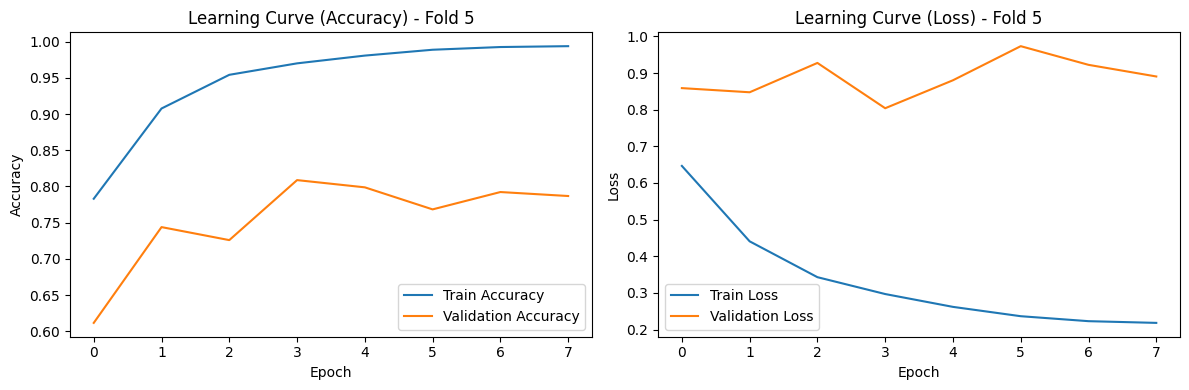

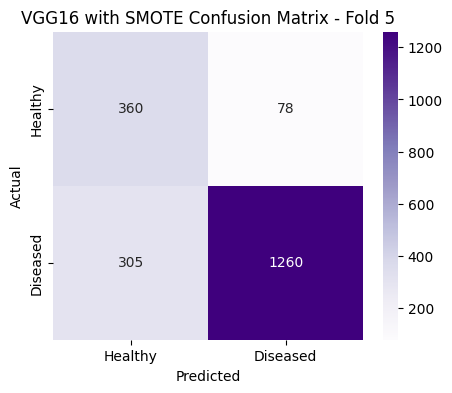


✅ Config Result → Accuracy: 0.7489

  Testing config: LR=1e-05, Dropout=0.5

==================== Model 4 (VGG16 with SMOTE): Fold 1/5 ====================
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 194ms/step - accuracy: 0.7224 - loss: 0.7324 - val_accuracy: 0.7061 - val_loss: 0.7061 - learning_rate: 1.0000e-05
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - accuracy: 0.8639 - loss: 0.5204 - val_accuracy: 0.7885 - val_loss: 0.5998 - learning_rate: 1.0000e-05
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 199ms/step - accuracy: 0.9239 - loss: 0.4075 - val_accuracy: 0.7066 - val_loss: 0.8051 - learning_rate: 1.0000e-05
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9556 - loss: 0.3324 - val_accuracy: 0.8035 - val_loss: 0.6462 - learning_rate: 1.0000e-05
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9707 - loss: 0.2938 - val_accuracy: 0.8009 - val_loss: 0.6480 - learning_rate: 3.0000e-06
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 193m

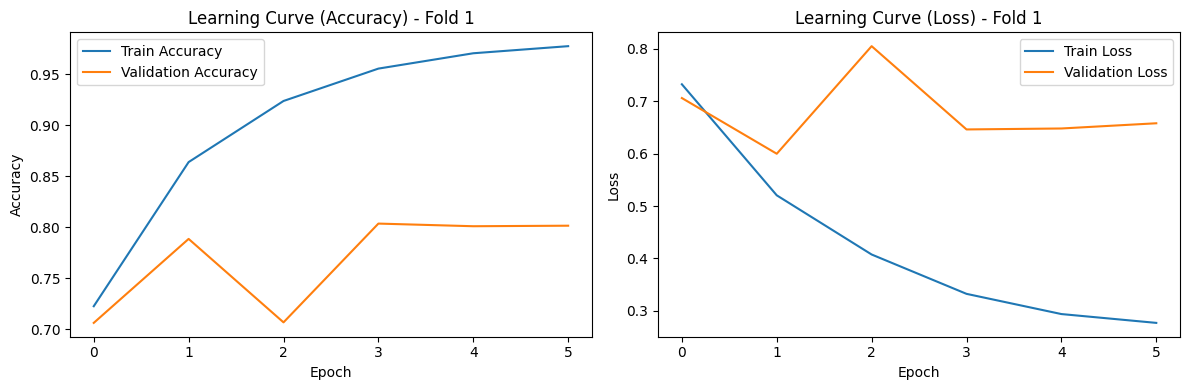

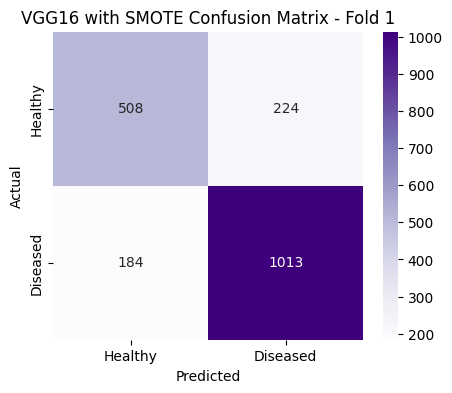


==================== Model 4 (VGG16 with SMOTE): Fold 2/5 ====================
Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 79s 195ms/step - accuracy: 0.7927 - loss: 0.6289 - val_accuracy: 0.5141 - val_loss: 0.9094 - learning_rate: 1.0000e-05
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9195 - loss: 0.4024 - val_accuracy: 0.6364 - val_loss: 1.1773 - learning_rate: 1.0000e-05
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - accuracy: 0.9614 - loss: 0.3141 - val_accuracy: 0.6302 - val_loss: 1.3916 - learning_rate: 1.0000e-05
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - accuracy: 0.9735 - loss: 0.2796 - val_accuracy: 0.6913 - val_loss: 1.5217 - learning_rate: 3.0000e-06
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 82s 192ms/step - accuracy: 0.9819 - loss: 0.2641 - val_accuracy: 0.6836 - val_loss: 1.6469 - learning_rate: 3.0000e-06

--- Results for Fold 2 ---
Accuracy: 0.5141
Classification Report:
              precision    recall  f1-score   support

  

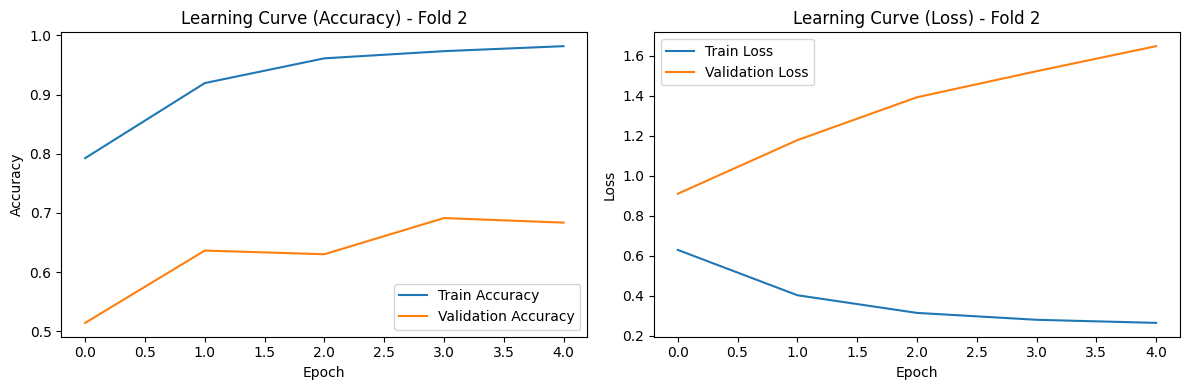

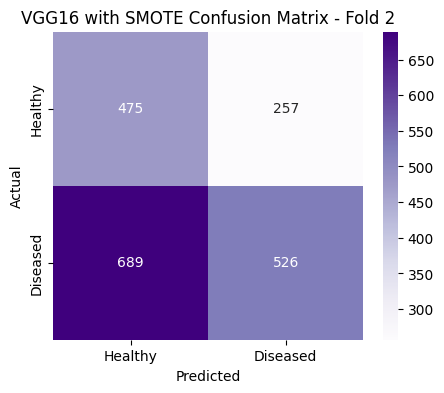


==================== Model 4 (VGG16 with SMOTE): Fold 3/5 ====================
Epoch 1/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 73s 206ms/step - accuracy: 0.7359 - loss: 0.7084 - val_accuracy: 0.6465 - val_loss: 0.8004 - learning_rate: 1.0000e-05
Epoch 2/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 204ms/step - accuracy: 0.8741 - loss: 0.5029 - val_accuracy: 0.6864 - val_loss: 0.7422 - learning_rate: 1.0000e-05
Epoch 3/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 79s 234ms/step - accuracy: 0.9246 - loss: 0.4040 - val_accuracy: 0.7365 - val_loss: 0.7517 - learning_rate: 1.0000e-05
Epoch 4/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9563 - loss: 0.3330 - val_accuracy: 0.7696 - val_loss: 0.7171 - learning_rate: 1.0000e-05
Epoch 5/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 205ms/step - accuracy: 0.9699 - loss: 0.2955 - val_accuracy: 0.8443 - val_loss: 0.6115 - learning_rate: 1.0000e-05
Epoch 6/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 69s 205ms/step - accuracy: 0.9777 - loss: 0.2690 - val_accuracy: 0.8311 - val_loss: 0

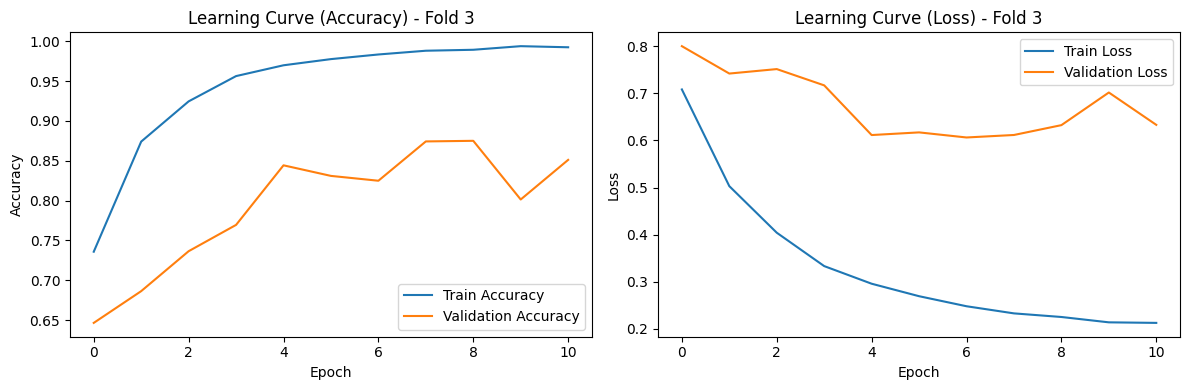

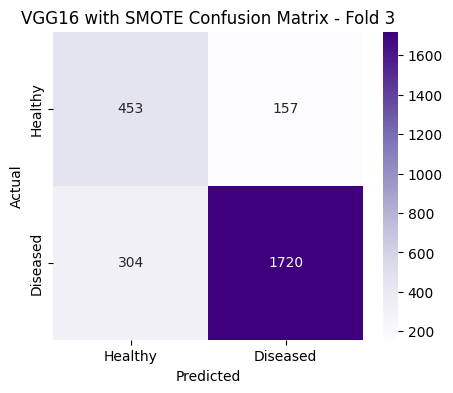


==================== Model 4 (VGG16 with SMOTE): Fold 4/5 ====================
Epoch 1/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.7541 - loss: 0.6816 - val_accuracy: 0.6449 - val_loss: 0.8150 - learning_rate: 1.0000e-05
Epoch 2/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.8939 - loss: 0.4571 - val_accuracy: 0.6319 - val_loss: 1.0045 - learning_rate: 1.0000e-05
Epoch 3/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - accuracy: 0.9411 - loss: 0.3624 - val_accuracy: 0.6760 - val_loss: 1.0179 - learning_rate: 1.0000e-05
Epoch 4/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 75s 200ms/step - accuracy: 0.9618 - loss: 0.3174 - val_accuracy: 0.7299 - val_loss: 1.0349 - learning_rate: 3.0000e-06
Epoch 5/15
376/376 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.9669 - loss: 0.3028 - val_accuracy: 0.6594 - val_loss: 1.1698 - learning_rate: 3.0000e-06

--- Results for Fold 4 ---
Accuracy: 0.6449
Classification Report:
              precision    recall  f1-score   support

  

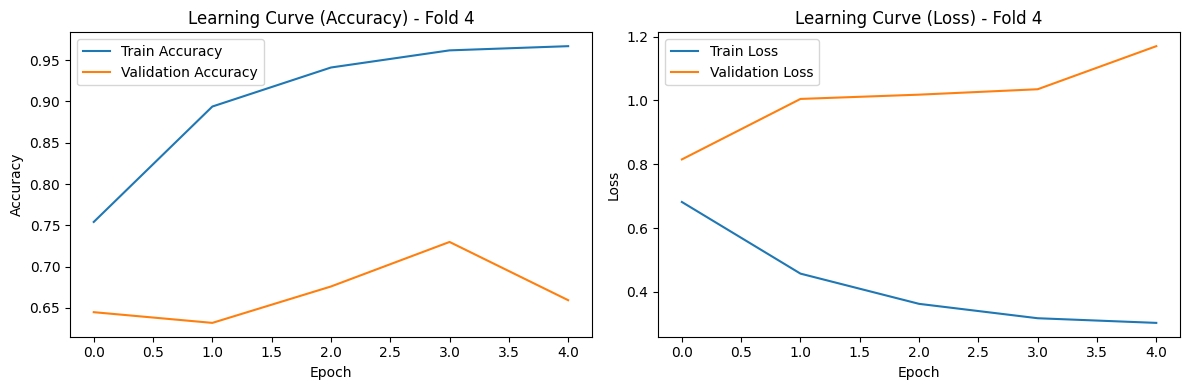

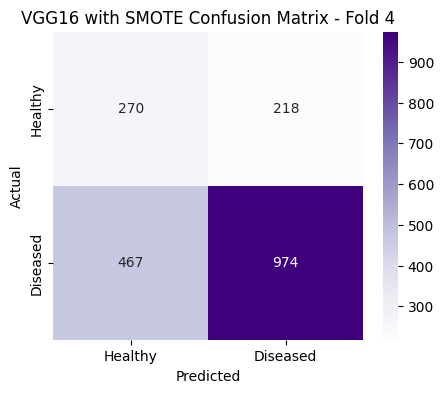


==================== Model 4 (VGG16 with SMOTE): Fold 5/5 ====================
Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 198ms/step - accuracy: 0.7363 - loss: 0.7081 - val_accuracy: 0.5856 - val_loss: 0.8738 - learning_rate: 1.0000e-05
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 195ms/step - accuracy: 0.8740 - loss: 0.5008 - val_accuracy: 0.7808 - val_loss: 0.7852 - learning_rate: 1.0000e-05
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9292 - loss: 0.3901 - val_accuracy: 0.8582 - val_loss: 0.6234 - learning_rate: 1.0000e-05
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 195ms/step - accuracy: 0.9555 - loss: 0.3337 - val_accuracy: 0.8278 - val_loss: 0.6866 - learning_rate: 1.0000e-05
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 195ms/step - accuracy: 0.9715 - loss: 0.2898 - val_accuracy: 0.8073 - val_loss: 0.7640 - learning_rate: 1.0000e-05
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.9809 - loss: 0.2644 - val_accuracy: 0.8328 - val_loss: 0

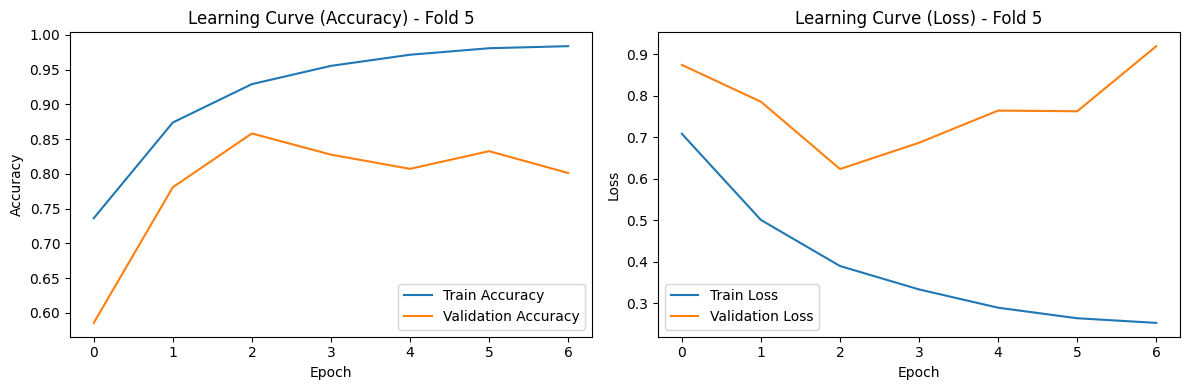

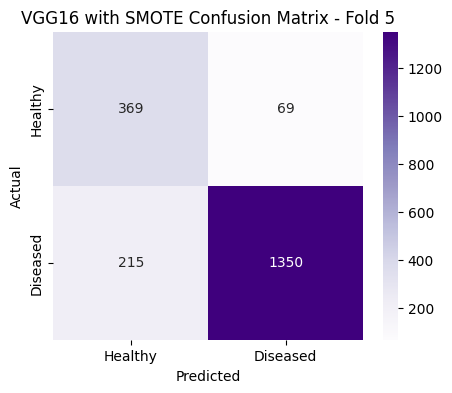


✅ Config Result → Accuracy: 0.7334

OVERALL VGG16 with SMOTE PERFORMANCE
Best Config → LR: 0.0001, Dropout: 0.3
Overall Accuracy: 0.7838

Overall Classification Report:
              precision    recall  f1-score   support

     Healthy       0.62      0.66      0.64      3000
    Diseased       0.86      0.83      0.85      7442

    accuracy                           0.78     10442
   macro avg       0.74      0.75      0.74     10442
weighted avg       0.79      0.78      0.79     10442



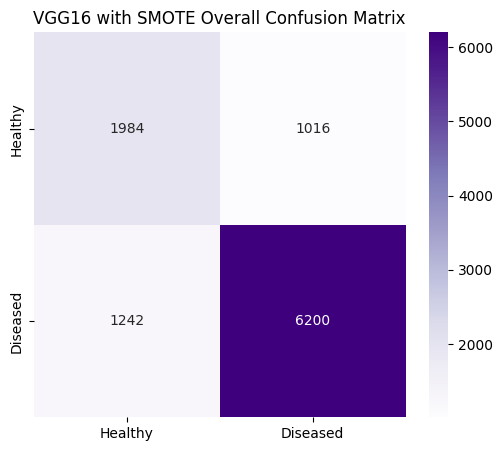

In [3]:
from imblearn.over_sampling import SMOTE
import gc

# Spatial augmentation layers for transfer learning models
data_augmentation_vgg = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Grid search hyperparameters
learning_rates = [1e-4, 1e-5]
dropout_rates = [0.3, 0.5]

best_acc = 0
best_config = None

# Containers for tracking performance across all folds
all_y_true_vgg, all_y_pred_vgg = [], []

# Loop over hyperparameters (Grid Search)
for lr in learning_rates:
    for dr in dropout_rates:

        print(f"\n  Testing config: LR={lr}, Dropout={dr}")

        temp_true, temp_pred = [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(all_patients, patient_labels)):
            fold_num = fold + 1
            print(f"\n{'='*20} Model 4 (VGG16 with SMOTE): Fold {fold_num}/{NUM_FOLDS} {'='*20}")

            # Isolate training and validation images based on patient IDs
            train_images = [img for pid in all_patients[train_idx] for img in patient_dict[pid]]
            val_images = [img for pid in all_patients[val_idx] for img in patient_dict[pid]]

            # Address class imbalance using SMOTE (applied on indices, not images directly)
            train_labels = np.array([get_binary_label(p) for p in train_images])
            indices = np.arange(len(train_images)).reshape(-1, 1)

            sm = SMOTE(random_state=SEED)
            resampled_idx, _ = sm.fit_resample(indices, train_labels)

            # Rebuild balanced dataset using resampled indices
            train_images = [train_images[i[0]] for i in resampled_idx]

            # Generate datasets
            train_ds = build_dataset(train_images, shuffle=True)
            val_ds = build_dataset(val_images, shuffle=False)

            # Initialize VGG16 with pre-trained ImageNet weights
            base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
            base_model.trainable = True

            # Freeze the first blocks and unfreeze the last 4 layers for fine-tuning
            for layer in base_model.layers[:-4]:
                layer.trainable = False

            # Build the sequential model architecture
            model = models.Sequential([
                data_augmentation_vgg,
                base_model,
                layers.GlobalAveragePooling2D(),
                layers.BatchNormalization(),  # Added to stabilize training
                layers.Dense(128, activation='relu',
                             kernel_regularizer=regularizers.l2(0.001)),  # Added L2 regularization
                layers.Dropout(dr), # Tuned dropout from grid search
                layers.Dense(1, activation='sigmoid') # Binary output
            ])

            # Compile with specified learning rate and optimizer
            model.compile(
                optimizer=optimizers.Adam(learning_rate=lr),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )

            # Halt training if the validation loss fails to improve
            early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

            # Reduce learning rate if validation stagnates (helps convergence)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

            # Execute training phase (Added history assignment here)
            history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[early_stopping, reduce_lr], verbose=1)

            # Generate predictions for the current fold
            y_probs = model.predict(val_ds, verbose=0)
            y_pred = (y_probs > 0.5).astype("int32").flatten()
            y_true = np.concatenate([labels.numpy() for _, labels in val_ds])

            # TensorFlow memory cleanup
            del model
            tf.keras.backend.clear_session()
            gc.collect()

            # Aggregate results for grid search evaluation
            temp_true.extend(y_true)
            temp_pred.extend(y_pred)

            # Print detailed metrics for the current fold
            print(f"\n--- Results for Fold {fold_num} ---")
            print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
            print("Classification Report:")
            print(classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased'], zero_division=1))

            # Plot Learning Curves
            plt.figure(figsize=(12, 4))

            # Accuracy Curve
            plt.subplot(1, 2, 1)
            plt.plot(history.history['accuracy'], label='Train Accuracy')
            plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
            plt.title(f'Learning Curve (Accuracy) - Fold {fold_num}')
            plt.ylabel('Accuracy')
            plt.xlabel('Epoch')
            plt.legend()

            # Loss Curve
            plt.subplot(1, 2, 2)
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title(f'Learning Curve (Loss) - Fold {fold_num}')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend()

            plt.tight_layout()
            plt.show()

            # Visualize fold confusion matrix with labels
            plt.figure(figsize=(5, 4))
            sns.heatmap(confusion_matrix(y_true, y_pred),
                        annot=True, fmt='d', cmap='Purples',
                        xticklabels=['Healthy', 'Diseased'],
                        yticklabels=['Healthy', 'Diseased'])
            plt.title(f'VGG16 with SMOTE Confusion Matrix - Fold {fold_num}')
            plt.ylabel('Actual')
            plt.xlabel('Predicted')
            plt.show()

        # Evaluate this hyperparameter combination
        acc = accuracy_score(temp_true, temp_pred)
        print(f"\n✅ Config Result → Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_config = (lr, dr)
            all_y_true_vgg = temp_true
            all_y_pred_vgg = temp_pred

# Final Overall Results for VGG16 with SMOTE (Best Config)
print("\n" + "="*50 + "\nOVERALL VGG16 with SMOTE PERFORMANCE\n" + "="*50)
print(f"Best Config → LR: {best_config[0]}, Dropout: {best_config[1]}")
print(f"Overall Accuracy: {best_acc:.4f}")

print("\nOverall Classification Report:")
print(classification_report(all_y_true_vgg, all_y_pred_vgg, target_names=['Healthy', 'Diseased'], zero_division=1))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_y_true_vgg, all_y_pred_vgg),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'])
plt.title('VGG16 with SMOTE Overall Confusion Matrix')
plt.show()